## Newsguard dataset 2020-2023

First, let's load the files.
Let's start with one of them.


In [1]:
import os
import pandas as pd
import random

folder_path = "newsguard_biyearly"
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Let's open a file (not the ones starting with ._, I think they are a MacOs artifact)
csv_files = [f for f in csv_files if not f.startswith('._')]
file=csv_files[0]
df = pd.read_csv(os.path.join(folder_path, file))
df.name=file




In [2]:
df.head()


,UUID,Domain,Parent Domain,Rating,Score,Last Updated,Country,Language,Does not repeatedly publish false content,Gathers and presents information responsibly,...,Twitter,YouTube,Instagram,Snapchat,LinkedIn,Pinterest,Main Point of Contact (name),Contact Phone Number,Contact Email,Contact Mail Form URL
0,35f341f9-d2c2-4d8f-9a00-910725e9647b,cbc.ca,NaN,T,100.0,1532095397020,US,en,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0c0e5e84-0b5c-47ff-bff4-94e987771e16,bitraped.com,naturalnews.com,N,12.5,1551286266563,US,en,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3ee37011-ba1f-4435-93d3-c72b59972b92,vogue.com,NaN,T,87.5,1532095401115,US,en,Yes,Yes,...,@voguemagazine,youtube.com/user/Americanvogue,@voguemagazine,@voguemagazine,NaN,NaN,NaN,NaN,NaN,NaN
3,33b3a070-62e2-42f5-b814-600784eb2402,foodscience.news,naturalnews.com,N,12.5,1551286316472,US,en,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,95d6acf5-a5cc-4cea-b34f-2431000b7391,stripes.com,NaN,T,100.0,1532095405883,US,en,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Columns

In [3]:
df.columns

Index(['UUID', 'Domain', 'Parent Domain', 'Rating', 'Score', 'Last Updated',
       'Country', 'Language', 'Does not repeatedly publish false content',
       'Gathers and presents information responsibly',
       'Regularly corrects or clarifies errors',
       'Handles the difference between news and opinion responsibly',
       'Avoids deceptive headlines',
       'Website discloses ownership and financing',
       'Clearly labels advertising',
       'Reveals who's in charge, including any possible conflicts of interest',
       'The site provides names of content creators, along with either contact or biographical information',
       'Brand Name', 'Wikipedia', 'Type of Content', 'Medium',
       'Print Publications', 'Scope of Coverage', 'Designated Market Area',
       'Paywall', 'Opinion/Advocacy Journalism', 'Orientation', 'Owner',
       'Type of Owner', 'Facebook', 'Twitter', 'YouTube', 'Instagram',
       'Snapchat', 'LinkedIn', 'Pinterest', 'Main Point of Contact (name)',


In [4]:
df.columns.nunique()

40

## Rows

In [5]:
df.shape


(2626, 40)

In [6]:
df.Domain.nunique()

2622

In [7]:
df["Parent Domain"].nunique()

67

In [8]:
df.name

'metadata-2019030100.csv'

So there were 2622 sources from 67 "parent domains", at least as March 2019 (from the filename)

In [9]:
## Let's open all of them 

In [10]:
df_total = pd.DataFrame()
for csv in csv_files:
    df = pd.read_csv(os.path.join(folder_path, csv))
    df.name=csv
    print(df.shape)
    # let's add the date from the name of the file
    # taking name of the file, removing the extension and "metadata-"
    df["file_date"]=csv.split(".")[0].split("-")[1]
    # make file_date a datetime, with the format YYYYMMDD00
    df["file_date"]=pd.to_datetime(df["file_date"], format="%Y%m%d00")
    
    df_total = pd.concat([df_total, df], axis=0)


(2626, 40)
(4029, 40)
(4885, 41)
(6770, 44)
(7131, 46)


(7664, 46)
(8661, 46)
(9430, 46)
(9926, 47)


We can observe that columns were added/removed over the years


In [11]:
# for all the files, compare the columns
columns_years = {}
for csv in csv_files:
    df=pd.read_csv(os.path.join(folder_path, csv))
    columns_years[csv.split(".")[0].split("-")[1]]=df.columns # saving a dict with the year/month as key and the columns as value to compare them
# subtracting the columns common to all the files
always_present_columns = set.intersection(*map(set, columns_years.values()))
# removing the columns that are always present from the columns of each file
for year in columns_years.keys():
    columns_years[year]=list(set(columns_years[year])-always_present_columns)
# lets show the remaining columns over the years
for year in columns_years.keys():
    columns_years[year].sort()
    print(year, columns_years[year])
    


2019030100 ['Paywall', 'Pinterest', 'Scope of Coverage', 'Snapchat', 'Wikipedia', 'YouTube']
2019090100 ['Paywall', 'Pinterest', 'Scope of Coverage', 'Snapchat', 'Wikipedia', 'YouTube']
2020030100 ['Paywall', 'Pinterest', 'Scope of Coverage', 'Snapchat', 'Topics', 'Wikipedia', 'YouTube']
2020090100 ['Flags', 'Paywall', 'Pinterest', 'Process Information', 'Scope of Coverage', 'Snapchat', 'Topics', 'Wikipedia', 'Youtube', 'myths']
2021030100 ['Android App', 'Flags', 'Paywall', 'Pinterest', 'Process Information', 'Scope of Coverage', 'Snapchat', 'Topics', 'Wikipedia', 'Youtube', 'iOS App', 'myths']
2021090100 ['Android App', 'Flags', 'Paywall', 'Pinterest', 'Process Information', 'Scope of Coverage', 'Snapchat', 'Topics', 'Wikipedia', 'Youtube', 'iOS App', 'myths']
2022030100 ['Android App', 'Flags', 'Paywall', 'Pinterest', 'Process Information', 'Scope of Coverage', 'Snapchat', 'Topics', 'Wikipedia', 'Youtube', 'iOS App', 'myths']
2022090100 ['Android App', 'Flags', 'Paywall', 'Pinterest

Let's see how the number of sources incresed over the years

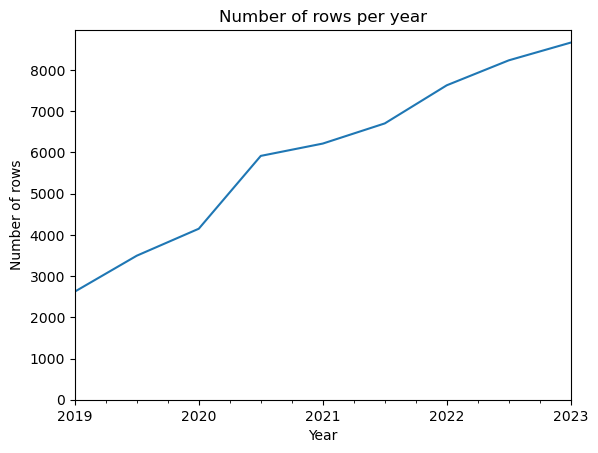

In [12]:

# raw count of rows per year   
# raw count of rows per year   
import matplotlib.pyplot as plt

counts = df_total.groupby(df_total.file_date).Domain.nunique()
counts.plot()
plt.ylim(0)
plt.xlabel('Year')
plt.ylabel('Number of rows')
plt.title('Number of rows per year')
plt.show()


In [13]:
df_total.groupby("Country").Language.value_counts()

Country  Language
ALL      en           7377
AT       de             59
AU       en            152
CA       en           1127
         fr             92
DE       de           2050
FR       fr           2528
GB       en           2660
IT       it           2735
NZ       en             10
US       en          42329
         es              3
Name: count, dtype: int64

## Review of German language sources

Let us now consider only the German ones as we only really care about them

In [14]:
# select only DE rows
df_de = df_total[df_total["Language"]=="de"]

In [15]:
df_de.shape

(2109, 55)

In [16]:
df_de.Domain.nunique()

363

In [17]:
df_de["Parent Domain"].nunique()

21

There are in total, overall in the course of two years (some could have been removed, let's check that later), 342 sources from 19 parent companies.

Let's see how this number changes through the years

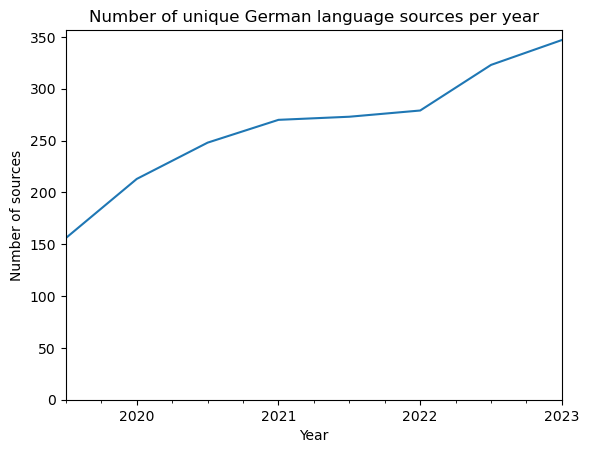

In [18]:
counts = df_de.groupby(df_de.file_date).Domain.nunique()
counts.plot()
# starting the plot from 0
plt.ylim(0)
plt.xlabel('Year')
plt.ylabel('Number of sources')
plt.title('Number of unique German language sources per year')
plt.savefig("german_sources_per_year.png", dpi=300)
plt.show()


Let's see what kind of sources were added throughout the years

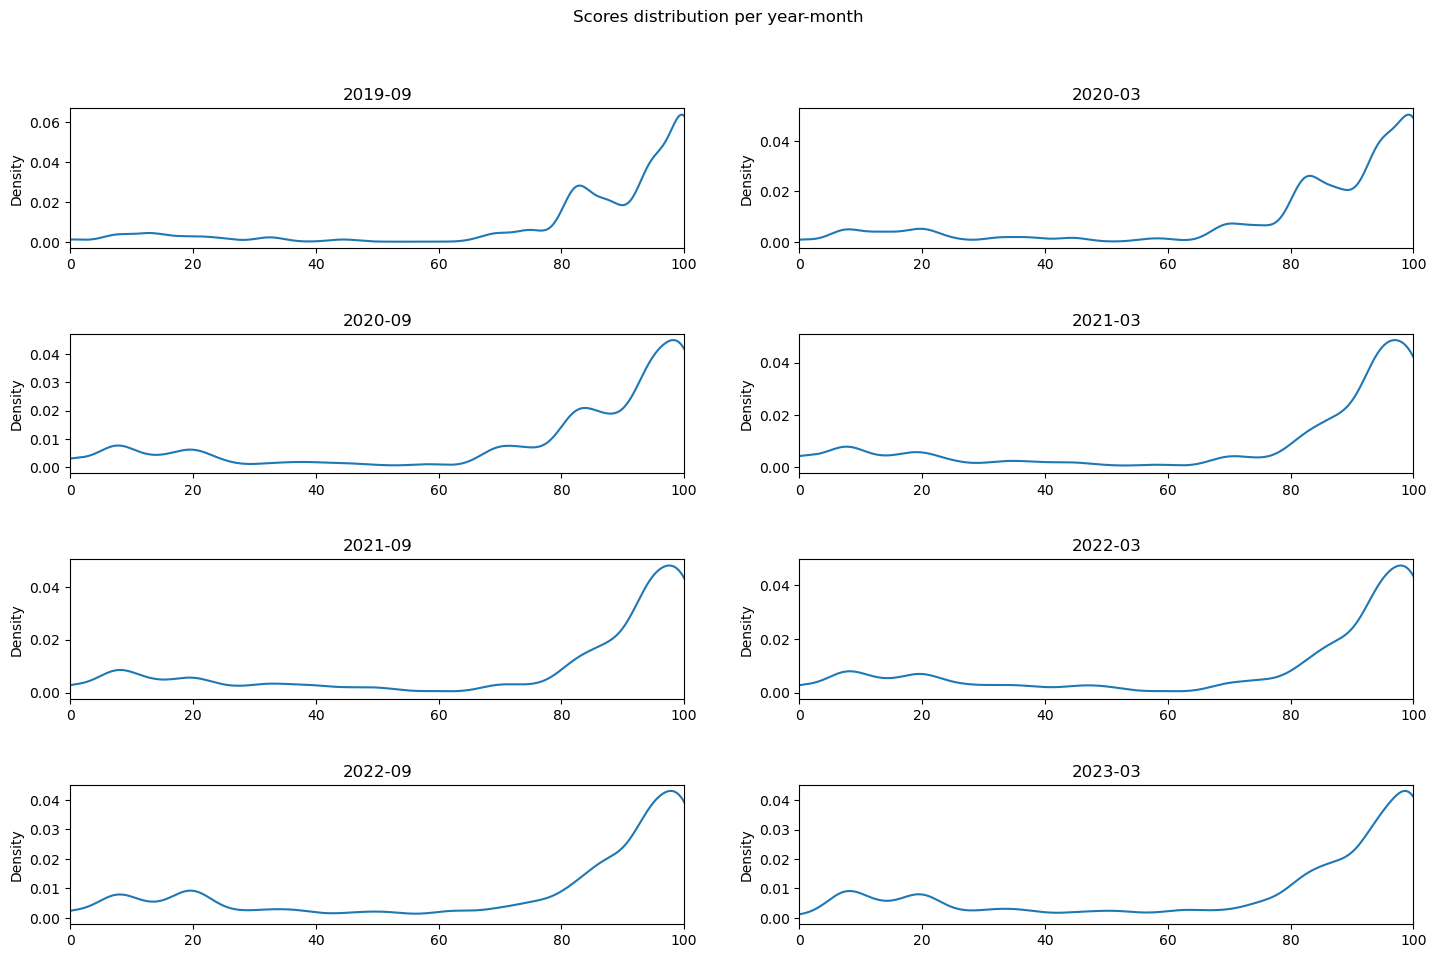

In [19]:
# lets examine the scores
df_de.groupby(df_de.file_date).Score.value_counts()

# plot the scores distribution per year
# one subplot per date, density plot
fig, axs = plt.subplots(4, 2, figsize=(15, 10))
fig.suptitle('Scores distribution per year-month')
for date in df_de.file_date.unique():
    # density plot that starts from 0 and ends at 100
    df_de[df_de.file_date==date].Score.plot.kde(ax=axs.flat[df_de.file_date.unique().tolist().index(date)], xlim=(0,100),bw_method=0.1)
    # set the title of the subplot
    # title as just year month
    axs.flat[df_de.file_date.unique().tolist().index(date)].set_title(date.strftime("%Y-%m"))
    

# distance between subplots
fig.tight_layout(pad=3.0)


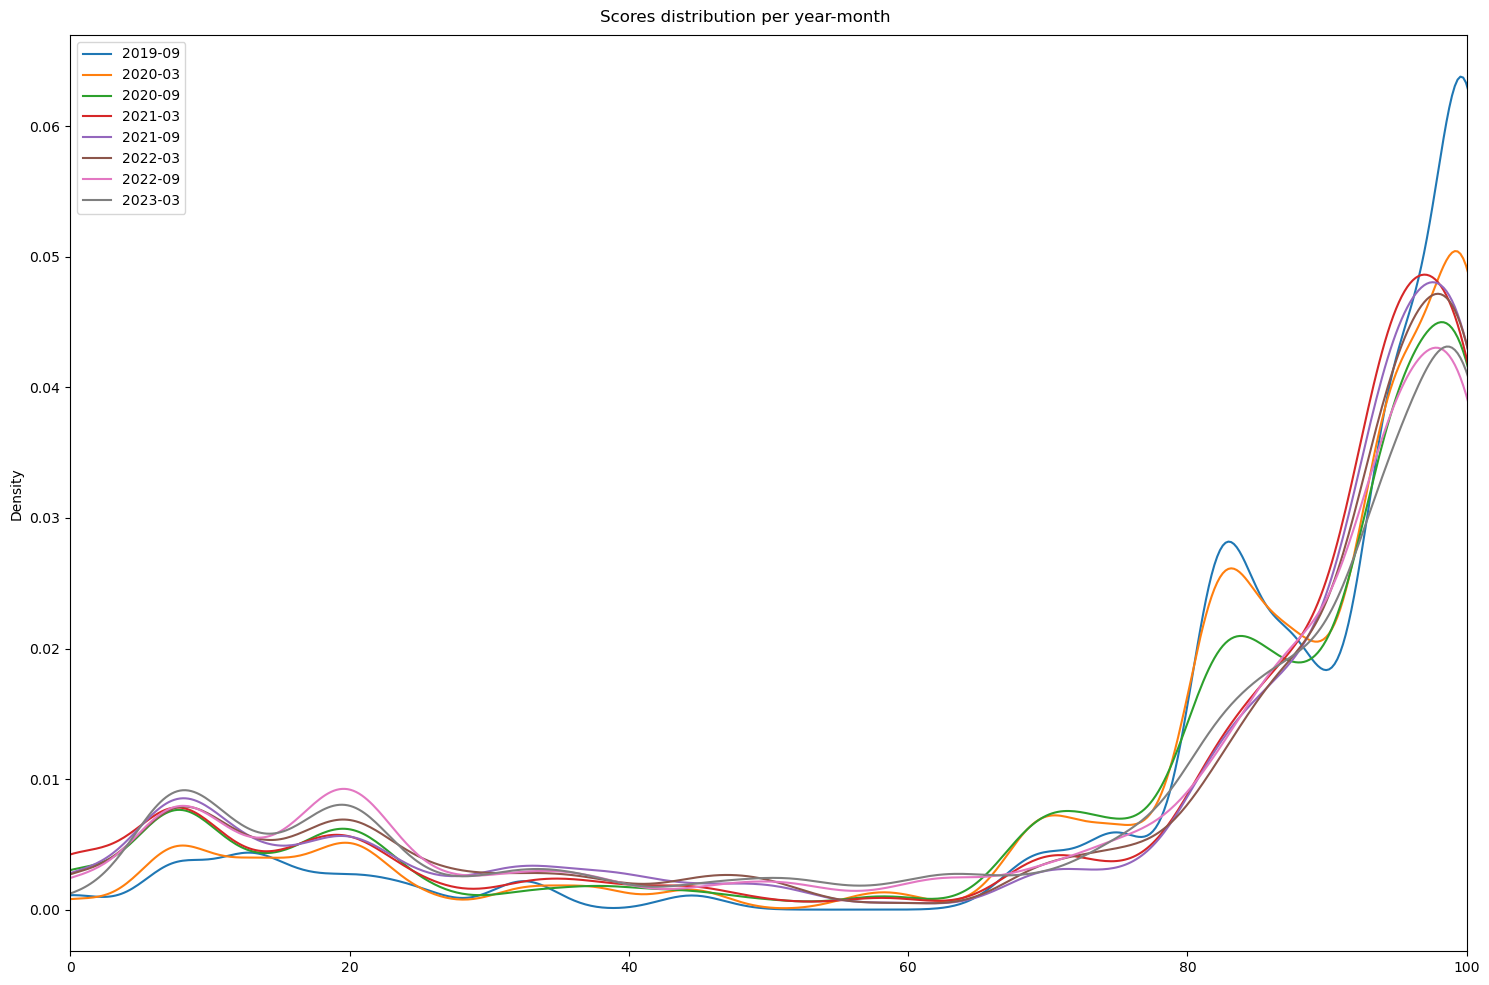

In [20]:
# same thing but all in the same plot to compare them better
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Scores distribution per year-month')
for date in df_de.file_date.unique():
    # density plot that starts from 0 and ends at 100
    df_de[df_de.file_date==date].Score.plot.kde(ax=ax, xlim=(0,100), label=date.strftime("%Y-%m"), bw_method=0.1)
# adding legend
ax.legend()
plt.tight_layout()
plt.savefig("scores_distribution_per_year.png", dpi=300)


plt.show()

Date: 2020-03-01 00:00:00
krone.at added
heilpraxisnet.de added
volksverpetzer.de added
gesundheitstrends.com added
hanfjournal.de added
aerztezeitung.de added
de.news-front.info added
n-tv.de changed from 100.0 to 92.5
unsere-natur.net added
gn-online.de added
bz-berlin.de changed from 82.5 to 95.0
rollingstone.de added
tlz.de added
focus.de changed from 87.5 to 95.0
swissinfo.ch added
zeit.de changed from 100.0 to 92.5
quarks.de added
nachrichten.at added
blog.halle-leaks.de added
nzz.ch added
jungewelt.de added
sn-online.de added
wize.life added
butenunbinnen.de added
waz-online.de added
nordbayern.de changed from 87.5 to 100.0
n23.tv added
netzfrauen.org added
oekotest.de added
wiesbadener-tagblatt.de added
hanfverband.de added
news-for-friends.de added
tag24.de changed from 75.0 to 87.5
vegpool.de added
pharmazeutische-zeitung.de added
compact-online.de changed from 12.5 to 20.0
fitforfun.de added
contra-magazin.com added
onmeda.de added
t3n.de added
deutsche-apotheker-zeitung.de 

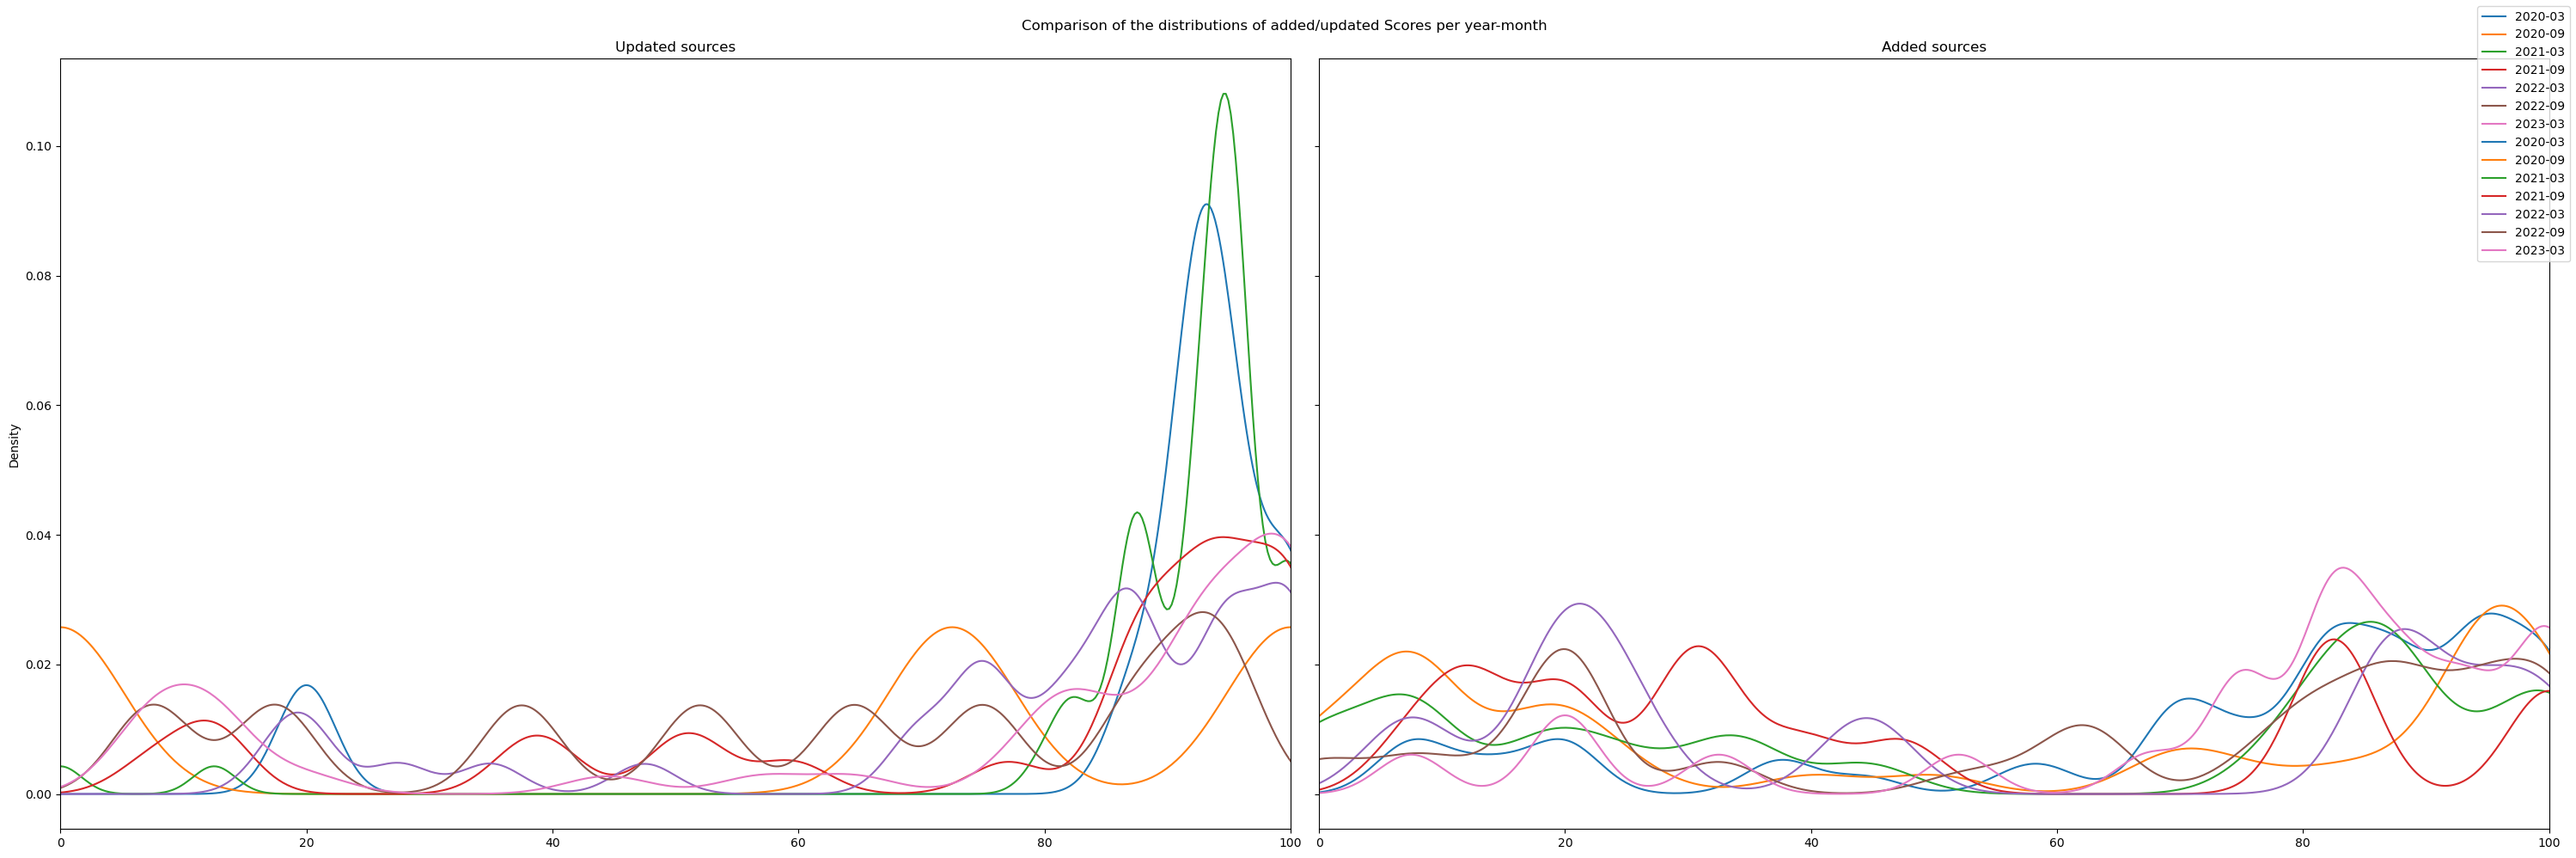

In [21]:
# same thing but all in the same plot to compare them better


fig, ax = plt.subplots(1,2,figsize=(30, 10), sharey=True)
fig.suptitle('Comparison of the distributions of added/updated Scores per year-month')
for i, date in enumerate(df_de.file_date.unique()):
    # get sources that were updated from the previous file_date and the score is different from before
    if i==0:
        continue
    print(f"Date: {date}")
    ind=i
    # use Domain as index
    previous=df_de[df_de.file_date==df_de.file_date.unique()[i-1]].set_index("Domain").dropna(subset=["Score"])
    current=df_de[df_de.file_date==date].set_index("Domain").dropna(subset=["Score"])
    updated=pd.DataFrame(index=[], columns=df_de.columns)
    added= pd.DataFrame(index=[], columns=df_de.columns)

    for i, row in current.iterrows():
        if i in previous.index:
            if row["Score"]!=previous.loc[i]["Score"]:
                print(f"{i} changed from {previous.loc[i]['Score']} to {row['Score']}")
                # append dictionary to updated
                updated=pd.concat([updated, pd.DataFrame(row).T])
        else:
            print(f"{i} added")
            added=pd.concat([added, pd.DataFrame(row).T])
                
    print(f"Number of rows updated: {updated.shape}")
    a=updated.Score.plot.kde(ax=ax[0], xlim=(0,100), label=date.strftime("%Y-%m"), bw_method=0.1)
    # add text to the line specifying the number of rows at the peak of the line


    added.Score.plot.kde(ax=ax[1], xlim=(0,100), label=date.strftime("%Y-%m"), bw_method=0.1)
    ax[0].set_title("Updated sources")
    ax[1].set_title("Added sources")
    
    

# adding legend
fig.legend()
plt.tight_layout()
plt.savefig("scores_distribution_per_year.png", dpi=300)


plt.show()

The scores appear to be distributed not normally, but skewed and increasing towards the maximum value (the majority of the sources have high scores). However, the scores have gotten less skewed towards the maximun recently (better and more detailed criterias/judgments? the inclusion of more niche but bad sources? a real trend in the german press?) (in my opinion the first option is the most likely)

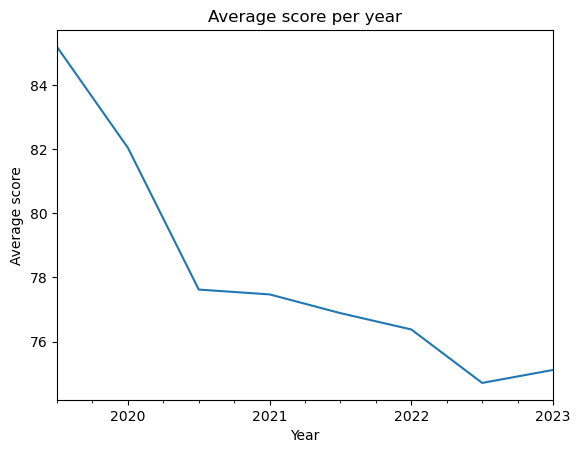

In [22]:
# to evidence this trend, let's see the average score by year/month
df_de.groupby(df_de.file_date).Score.mean().plot()
plt.xlabel('Year')
plt.ylabel('Average score')
plt.title('Average score per year')
plt.show()

Now let's make the score a category (like low, high), so we can clearly group them over the years

C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\3636696867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_de["score_cat"]=df_de.Score.apply(lambda x: "very positive" if x>=75 else ("positive" if x>=50 else ("negative" if x>=25 else "very negative")))


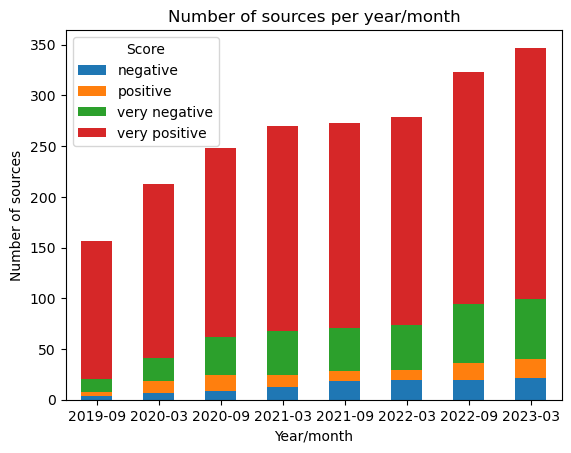

In [23]:
# let's the scores to very positive, positive, negative, very negative (100-75, 74-50, 49-25, 24-0)
df_de["score_cat"]=df_de.Score.apply(lambda x: "very positive" if x>=75 else ("positive" if x>=50 else ("negative" if x>=25 else "very negative")))
# and now we can plot the distribution of the score types per year

df_de.groupby(df_de.file_date).score_cat.value_counts().unstack().plot(kind='bar', stacked=True)
dates=df_de.file_date.unique()
# format x axis to show only the year-month
plt.xlabel('Year/month')
plt.ylabel('Number of sources')
plt.title('Number of sources per year/month')
# formatting the x axis to show only the year-month and the legend to have a decent title
plt.gca().get_legend().set_title('Score')
# using dates as xticks, formatted as year-month
plt.xticks(range(len(dates)), [date.strftime("%Y-%m") for date in dates], rotation=0)
plt.show()

Now let's see which sources were removed and added throughout the years

In [24]:
sources_diff = {}

for date in dates[1:]:
    # lets get a list of the sources added in the current date from the last one
    added=set(df_de[df_de.file_date==date].Domain.tolist())-set(df_de[df_de.file_date==dates[dates.tolist().index(date)-1]].Domain.tolist())
    removed=set(df_de[df_de.file_date==dates[dates.tolist().index(date)-1]].Domain.tolist())-set(df_de[df_de.file_date==date].Domain.tolist())
    sources_diff[date]=added, removed
    
# print the number of sources added and removed
for date in sources_diff.keys():
    print(f"{date.strftime('%Y-%m')} Sources added: {len(sources_diff[date][0])}, Sources removed: {len(sources_diff[date][1])}")

2020-03 Sources added: 57, Sources removed: 0
2020-09 Sources added: 35, Sources removed: 0
2021-03 Sources added: 24, Sources removed: 2
2021-09 Sources added: 15, Sources removed: 12
2022-03 Sources added: 9, Sources removed: 3
2022-09 Sources added: 48, Sources removed: 4
2023-03 Sources added: 24, Sources removed: 0


Now a detailed list

In [25]:
# printing the names of the sources added and removed per date
# in markdown 
from IPython.display import Markdown, display

# Define the table headers
headers = ["Date", "Sources added", "Sources removed"]

# Construct the table as a string
table = "| " + " | ".join(headers) + " |\n" + "| " + " | ".join(["---"] * len(headers)) + " |\n"
for date in sources_diff.keys():
    table += f"| {date.strftime('%Y-%m')} | {', '.join(sources_diff[date][0])} | {', '.join(sources_diff[date][1])} |\n"

# Display the table as Markdown
display(Markdown(table))

| Date | Sources added | Sources removed |
| --- | --- | --- |
| 2020-03 | deutschland-kurier.org, blog.halle-leaks.de, hanfjournal.de, aerztezeitung.de, kopp-report.de, aerzteblatt.de, rollingstone.de, netzpolitik.org, volksverpetzer.de, netzfrauen.org, news-for-friends.de, scinexx.de, sn-online.de, oekotest.de, pnn.de, tlz.de, hanfverband.de, t3n.de, rheinische-anzeigenblaetter.de, heute.at, anti-spiegel.ru, butenunbinnen.de, wiesbadener-tagblatt.de, heilpraxisnet.de, n23.tv, jungefreiheit.de, deutsche-apotheker-zeitung.de, jungewelt.de, bergedorfer-zeitung.de, pharmazeutische-zeitung.de, quarks.de, frankenpost.de, landdergesundheit.de, freiewelt.net, nachrichten.at, contra-magazin.com, onmeda.de, gesundheitstrends.com, swissinfo.ch, vegpool.de, watergate.tv, berlinertageszeitung.de, fitforfun.de, gn-online.de, waz-online.de, rnd.de, unsere-natur.net, wikipedia.org, nzz.ch, berliner-express.com, presseportal.de, swp.de, de.news-front.info, krone.at, youtube.com, regenbogen.de, wize.life |  |
| 2020-09 | wizelife.de, sciencefiles.org, connectiv.events, kenfm.de, srf.ch, politaia.org, andreaskalcker.com, altermedzentrum.com, fimico.de, tagesanzeiger.ch, politikstube.com, einreich.de, diepresse.com, liebeisstleben.de, kla.tv, fudder.de, heidelberg24.de, snap4face.com, ef-magazin.de, praxisvita.de, insuedthueringen.de, freitag.de, dieunbestechlichen.com, marialourdesblog.com, achgut.com, mittelhessen.de, politikversagen.net, op-marburg.de, zvw.de, wissenschaft.de, zentrum-der-gesundheit.de, 20min.ch, kurier.at, indexexpurgatorius.wordpress.com, legitim.ch |  |
| 2021-03 | youtu.be, uncutnews.ch, wg.neopresse.com, infektionsschutz.de, bundesgesundheitsministerium.de, morgenweb.de, soester-anzeiger.de, viralvirus.de, netdoktor.de, liebeisstleben.net, deutsche-wirtschafts-nachrichten.de, zuerst.de, sr.de, landeszeitung.de, apotheken-umschau.de, rubikon.news, uncut-news.ch, opposition24.com, ga.de, swprs.org, reitschuster.de, naturstoff-medizin.de, lr-online.de, de.rt.com | de.sputniknews.com, news-for-friends.de |
| 2021-09 | corona-blog.net, rki.de, deutschlandkurier.de, qs24.tv, pei.de, snanews.de, bzga.de, flinkfeed.com, hildesheimer-allgemeine.de, stimme.de, 2020news.de, report24.news, corona-transition.org, mediagnose.de, neopresse.com | wizelife.de, bento.de, berliner-express.com, wiesbadener-tagblatt.de, wg.neopresse.com, watergate.tv, snap4face.com, ze.tt, bergedorfer-zeitung.de, politaia.org, general-anzeiger-bonn.de, wize.life |
| 2022-03 | impfkritik.de, nd-aktuell.de, apolut.net, dewezet.de, anonymousnews.org, exxpress.at, mannheimer-morgen.de, top20radio.tv, mmnews.de | anonymousnews.ru, viralvirus.de, kenfm.de |
| 2022-09 | nn.de, cnv-medien.de, derwaechter.org, rtde.website, vienna.at, corona-live.at, corona-solution.com, dietagespresse.com, kurier.de, vogue.de, deraktionaer.de, viralvirus.de, siegener-zeitung.de, salzburg24.at, rtde.site, rtde.tech, nationalgeographic.de, ansage.org, bw24.de, cz.de, lkz.de, multipolar-magazin.de, derwaechter.net, zackzack.at, sachsen-fernsehen.de, oe24.at, noen.at, rtde.team, rtde.world, kleinezeitung.at, puls24.at, politik-live.at, anonymousnews.ru, az-online.de, news4teachers.de, rtde.live, buzzfeed.de, servustv.com, rtde.xyz, transition-news.org, business-live.at, rtde.life, news.de, faktastisch.de, contra24.online, mz.de, giessener-allgemeine.de, tt.com | liebeisstleben.de, contra-magazin.com, tagesstimme.com, corona-transition.org |
| 2023-03 | miss.at, fuldaerzeitung.de, falter.at, indexexpurgatorius.mx, heftig.de, radiogong.de, futurezone.at, gentside.de, unser-mitteleuropa.com, tvo.de, radiobrocken.de, remszeitung.de, tip-berlin.de, contra-magazin.com, capital.de, wienerzeitung.at, esslinger-zeitung.de, sn.at, tagesstimme.com, schwaebische-post.de, corona-transition.org, eltern.de, freilich-magazin.com, profil.at |  |


## Distribution of the various attributes

Now that we've seen some temporal variation, let's look at the latest dataset (the most up to date one) to see how some of the attributes are distributed

In [26]:
df_de_last = df_de[df_de.file_date==dates[-1]]

In [27]:
df_de_last.shape

(347, 56)

In [28]:
df_de_last["Parent Domain"].nunique()

15

313 sources in the latest iteration available, 12 parent domains


Let's check when they were last updated

In [29]:
# the last update field is in unix epoch milliseconds time i presume, lets convert it
df_de_last["Last Updated"] = pd.to_datetime(df_de_last["Last Updated"], unit='ms')


C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\1529352692.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_de_last["Last Updated"] = pd.to_datetime(df_de_last["Last Updated"], unit='ms')


In [30]:
# make date only day and month and year
df_de_last["Last Updated"] = df_de_last["Last Updated"].dt.date

C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\3992991148.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_de_last["Last Updated"] = df_de_last["Last Updated"].dt.date


In [31]:
df_de_last["Last Updated"].describe()

count            347
unique           106
top       2023-02-20
freq              19
Name: Last Updated, dtype: object

In [32]:
df_de_last["Last Updated"].describe()


count            347
unique           106
top       2023-02-20
freq              19
Name: Last Updated, dtype: object

Now the rest of the columns

In [33]:
# let's see the nas
df_de_last.isna().sum().sort_values()

UUID                                                                                                    0
Targeted Audience                                                                                       0
file_date                                                                                               0
Opinion/Advocacy Journalism                                                                             0
Language                                                                                                0
Country                                                                                                 0
score_cat                                                                                               0
Domain                                                                                                  0
Last Updated                                                                                            0
Rating                                        

Weird thing: some sources don't have a score

In [34]:
df_de_last[df_de_last["Score"].isna()]

,UUID,Domain,Parent Domain,Rating,Score,Last Updated,Country,Language,Does not repeatedly publish false content,Gathers and presents information responsibly,...,iOS App,Android App,Original Reporting,Targeted Audience,Contact Mail Form URL.1,Other,False Narratives,Communities Served,BrandGuard Segments,score_cat
2724,a65efe1b-8ed4-4d80-8b40-2ec8c9e8e3aa,youtu.be,youtube.com,P,NaN,2022-12-27,DE,de,NaN,NaN,...,https://apps.apple.com/fr/app/youtube/id544007664,https://play.google.com/store/apps/details?id=...,Yes,"International,National,Regional,Local",NaN,https://www.pinterest.com/YouTube/,"f7aa45ce-6b94-42b9-99a8-a8b347b6dbfa,54d48231-...",NaN,NaN,very negative
2725,1241ed36-7b40-4d5e-b2c4-45f6e95d3f31,youtube.com,youtube.com,P,NaN,2022-12-27,DE,de,NaN,NaN,...,https://apps.apple.com/fr/app/youtube/id544007664,https://play.google.com/store/apps/details?id=...,Yes,"International,National,Regional,Local",NaN,https://www.pinterest.com/YouTube/,"f7aa45ce-6b94-42b9-99a8-a8b347b6dbfa,54d48231-...",NaN,NaN,very negative
3262,0aeb3bcd-24c5-4421-9c22-1a1ea2db5c42,der-postillon.com,NaN,S,NaN,2022-12-06,DE,de,NaN,NaN,...,https://apps.apple.com/us/app/the-postillon/id...,https://play.google.com/store/apps/details?id=...,Yes,"International,National",NaN,NaN,NaN,NaN,NaN,very negative
3621,d285ced6-f838-46e5-aca2-c1aef270375f,wikipedia.org,NaN,P,NaN,2022-11-18,DE,de,NaN,NaN,...,https://apps.apple.com/us/app/wikipedia/id3247...,https://play.google.com/store/apps/details?id=...,NaN,"National,International,Regional,Local",NaN,NaN,NaN,NaN,NaN,very negative
6451,9a05ddc4-0860-4a34-aa14-da2c35e871f3,dietagespresse.com,NaN,S,NaN,2022-08-25,AT,de,NaN,NaN,...,https://apps.apple.com/de/app/tagespresse/id10...,https://play.google.com/store/apps/details?id=...,Yes,"National,International",NaN,NaN,NaN,NaN,NaN,very negative


Wikipedia and youtube make sense as special cases, the others a bit less

In [35]:
# Score by rating
df_de_last.groupby(df_de_last.Rating).Score.value_counts()

Rating  Score
N       7.5      22
        20.0     17
        12.5      8
        17.5      4
        32.5      4
        52.0      4
        37.5      3
        44.5      3
        25.0      3
        0.0       2
        47.5      2
        35.0      2
        30.0      2
        57.0      2
        59.5      1
        50.0      1
        39.5      1
        27.5      1
        15.0      1
T       100.0    96
        95.0     50
        87.5     33
        92.5     25
        82.5     22
        75.0      9
        80.0      4
        62.5      4
        77.5      3
        82.0      3
        69.5      2
        85.0      2
        70.0      2
        64.5      2
        67.5      1
        90.0      1
Name: count, dtype: int64

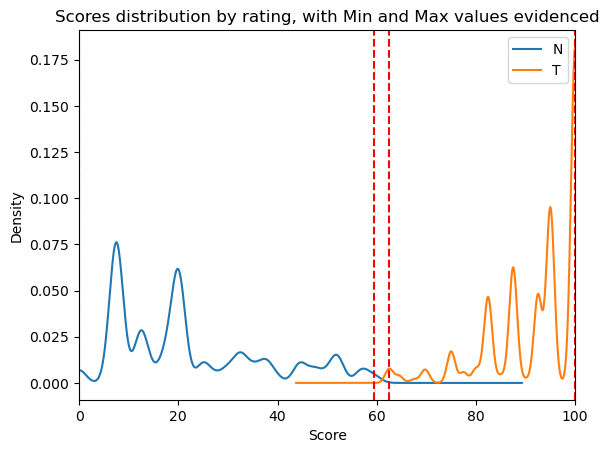

In [36]:
# let's see the distribution of the scores by rating for T and N
df_de_last.loc[df_de_last.Rating.isin(["T","N"]),].groupby(df_de_last.Rating).Score.plot.kde(xlim=(0,100), bw_method=0.09, legend=True)
# make each line stop where they have the min and max value
for rating in df_de_last.loc[df_de_last.Rating.isin(["T","N"]),].Rating.unique():
    plt.axvline(df_de_last.loc[df_de_last.Rating==rating,].Score.min(), color='red', linestyle='--')
    
    plt.axvline(df_de_last.loc[df_de_last.Rating==rating,].Score.max(), color='red', linestyle='--')
plt.xlabel('Score')
plt.ylabel('Density')
plt.title('Scores distribution by rating, with Min and Max values evidenced')
plt.show()

I imagine that the T type of sources are trustworthy and N is non-trustworthy, this Rating column is not documented but the cutoff appears to be at 60, they mention on their website that sources under 60 have to be "considered with caution"

In [37]:
# an helper function for all of this boolean columns
def plot_yesno(col,df=df_de_last):
    df_de_last[col].value_counts().plot(kind='bar')
    plt.xlabel('Value')
    plt.ylabel('Number of sources')
    plt.title(f'Number of sources respecting the "{col}" criteria')
    

## The criterias

1. "Does not repeatedly publish false content: The site does not repeatedly and currently produce content that has been found to be clearly and significantly false, and which has not been quickly and prominently corrected. There is a “high bar” for failing this criterion. In practice, it means that on any given day the website is likely to display significantly false content. (22 Points.)"

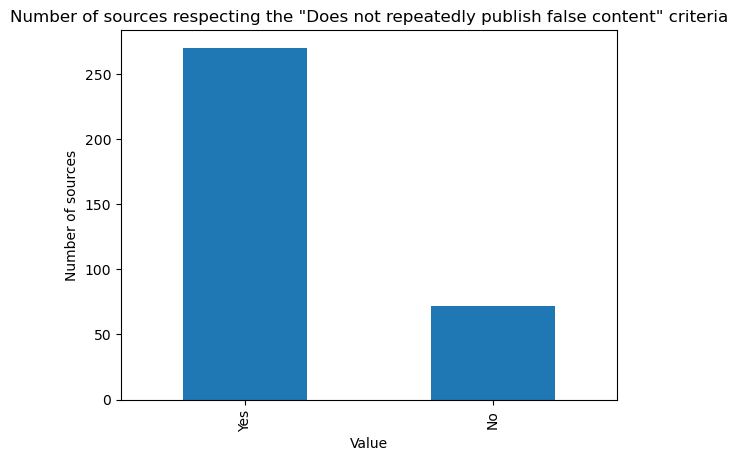

In [38]:
#Does not repeatedly publish false content                                                               4
plot_yesno("Does not repeatedly publish false content")

2. "Gathers and presents information responsibly: Content providers are generally fair and accurate in reporting and presenting information. They reference multiple sources, preferably those that present direct, firsthand information on a subject or event or from credible secondhand news sources, and they do not egregiously distort or misrepresent information to make an argument or report on a subject. (18 Points)"

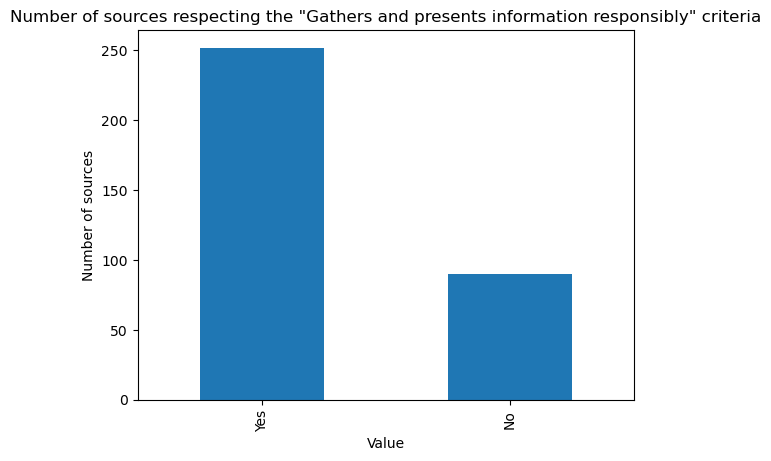

In [39]:
#Gathers and presents information responsibly                                                            4
plot_yesno("Gathers and presents information responsibly")

3. "Regularly corrects or clarifies errors: The site has effective practices for identifying errors and for publishing clarifications and corrections, transparently acknowledges errors, and does not regularly leave significant false content uncorrected. (12.5 Points)"

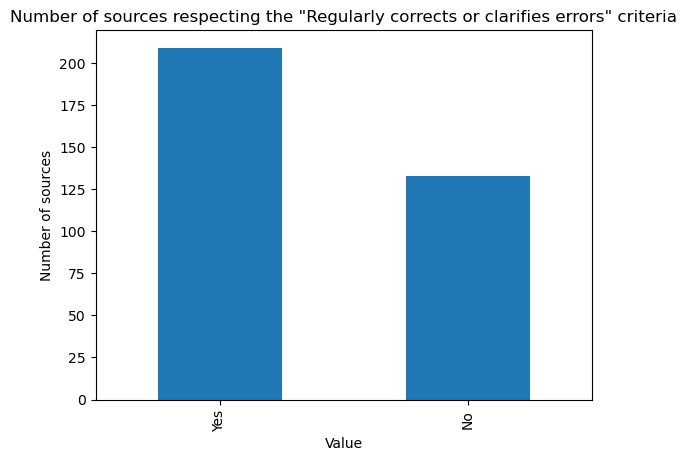

In [40]:
#Regularly corrects or clarifies errors                                                                 4
plot_yesno("Regularly corrects or clarifies errors")

4. Handles the difference between news and opinion responsibly: Content providers who convey the impression that they report news or a mix of news and opinion distinguish opinion from news reporting, and when reporting news, do not egregiously cherry pick facts or stories to advance opinions. Content providers who advance a particular point of view disclose that point of view. (12.5 Points)

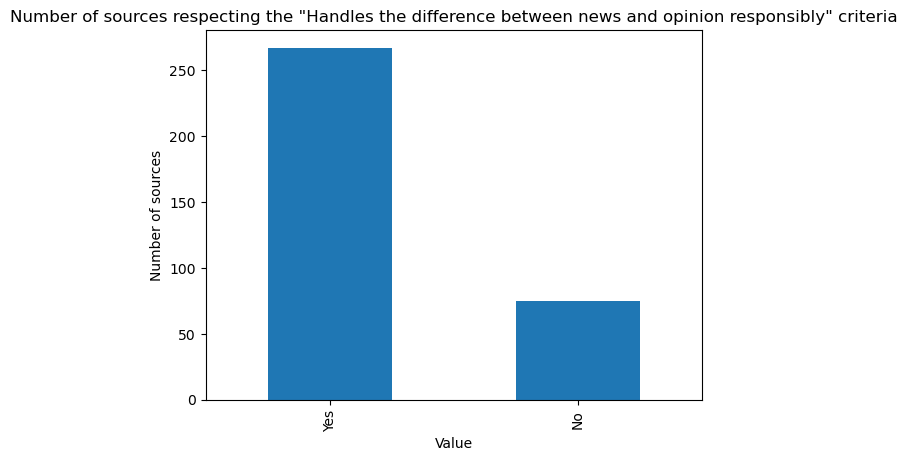

In [41]:
#Handles the difference between news and opinion responsibly                                            4
plot_yesno("Handles the difference between news and opinion responsibly")

5. "Avoids deceptive headlines: The site generally does not publish headlines that include false information, significantly sensationalize, or otherwise do not reflect what is actually in the content under the headline. (10 Points)" 

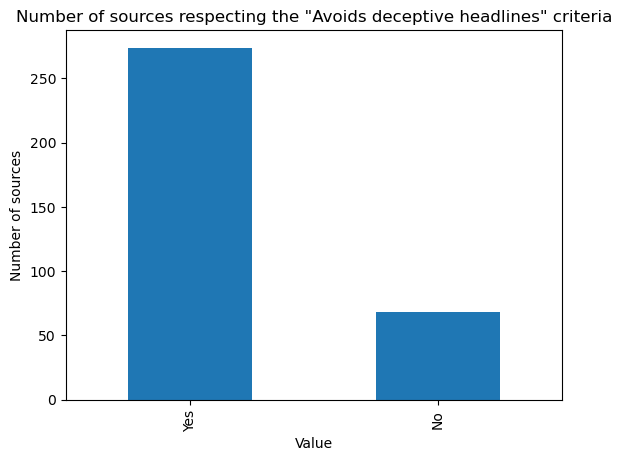

In [42]:
#Avoids deceptive headlines                                                                             4
plot_yesno("Avoids deceptive headlines")

6. "Website discloses ownership and financing: The site discloses in a user-friendly manner its ownership and/or financing, as well as any notable political affiliations or financial interests relevant to the site’s coverage held by those with a significant financial interest in the site. Put simply, the reader should know who is funding the content and what relevant interests the owner or funder might have in the content. (7.5 Points)"

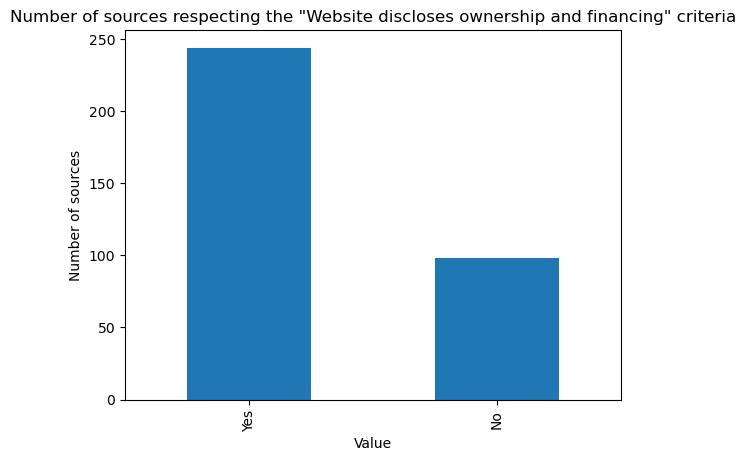

In [43]:
# Website discloses ownership and financing
plot_yesno("Website discloses ownership and financing")

7. "Clearly labels advertising: The site makes clear which content is paid for and which is not. (7.5 Points)"

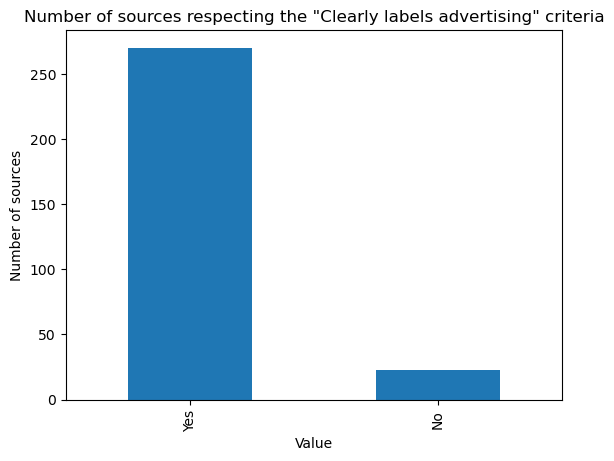

In [44]:
#Clearly labels advertising
plot_yesno("Clearly labels advertising")

8. "Reveals who’s in charge, including possible conflicts of interest: Those in charge of the content are identified on the site, and there is a way for readers to contact the site about editorial issues. In other words, the reader is told who is in charge of deciding what content is published. (5 Points)"

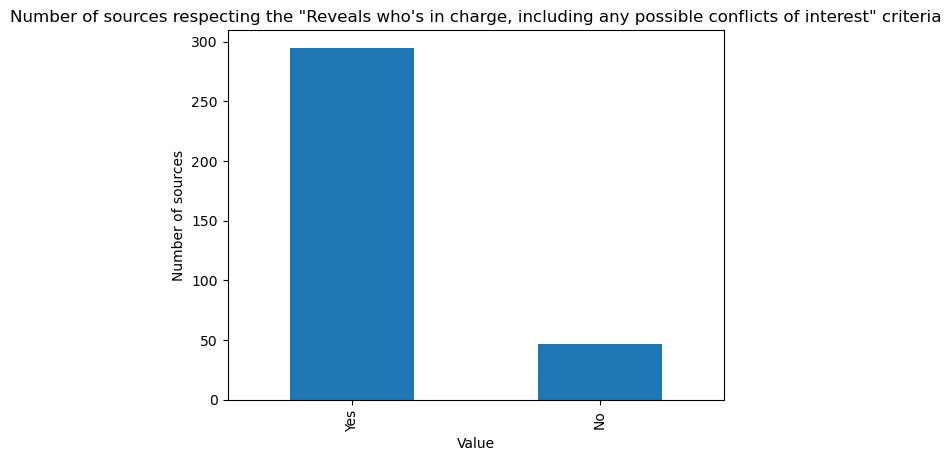

In [45]:
#Reveals who's in charge, including any possible conflicts of interest
plot_yesno("Reveals who's in charge, including any possible conflicts of interest")

9. The site provides the names of content creators, along with either contact or biographical information: Information about those producing the content is made accessible on the site, and it is generally clear who produces which content. (5 Points) 

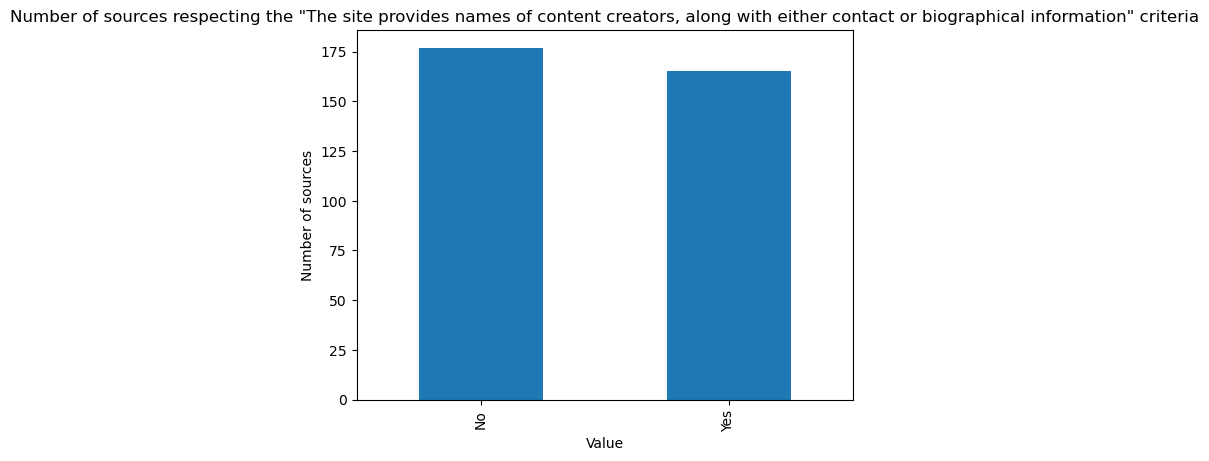

In [46]:
#The site provides names of content creators, along with either contact or biographical information
plot_yesno("The site provides names of content creators, along with either contact or biographical information")

At last, let's see if the remaining columns have some interesting intel

In [47]:
# dropping every column reviewed up to now
df_de_other=df_de_last.drop(["score_cat","file_date","Contact Mail Form URL","Contact Mail Form URL.1","UUID","Does not repeatedly publish false content","Gathers and presents information responsibly","Regularly corrects or clarifies errors","Handles the difference between news and opinion responsibly","Avoids deceptive headlines","Website discloses ownership and financing","Clearly labels advertising","Reveals who's in charge, including any possible conflicts of interest","The site provides names of content creators, along with either contact or biographical information","Country","Language","Last Updated", "iOS App","Android App"],axis=1)
# dropping social media columns
df_de_other=df_de_other.drop(["Facebook","Twitter","Instagram","Youtube","Pinterest","LinkedIn"],axis=1)

In [48]:
df_de_other.Wikipedia.value_counts() # they should drop this

Series([], Name: count, dtype: int64)

In [49]:
df_de_other["Communities Served"].value_counts() # also empty

Series([], Name: count, dtype: int64)

In [50]:
df_de.Topics.value_counts() 

Topics
Political news or commentary                                                                799
Health or medical information                                                               155
Political news or commentary,Conspiracy theories or hoaxes                                   98
Health or medical information,Political news or commentary                                   34
Health or medical information,Political news or commentary,Conspiracy theories or hoaxes     34
                                                                                           ... 
General / Local News,Political news or commentary,General News                                1
Conspiracy theories or hoaxes,Political news or commentary,COVID-19 misinformation            1
Local News,General News                                                                       1
Political news or commentary,General / Local News,Sports and athletics                        1
General / Local News,Local News,P

## Popularity
There is no popularity measure in the dataset, I will try to come up with one by myself

In [51]:
websites_test=df_de_last.Domain.sample(10)

import requests

def get_similar_rank(url, api_key="594a88fb2d4e4c0983ea344bcac761d6"):
    # Set up the API endpoint and parameters
    endpoint = f'https://api.similarweb.com/v1/similar-rank/{url}/rank'
    params = {
        'api_key': api_key
    }

    # Send a GET request to the API endpoint with the parameters
    response = requests.get(endpoint, params=params)

    # Check if the request was successful
    if response.status_code == 200:
        # Extract the global rank from the response JSON
        data = response.json()
        global_rank = data['similar_rank']['rank']
        return global_rank
    else:
        print('Error:', response.status_code)

In [52]:
for website in websites_test:
    print(f"Website: {website}, Global Rank: {get_similar_rank(website)}")

Website: uncutnews.ch, Global Rank: 61030
Error: 404
Website: de.news-front.info, Global Rank: None
Website: tagesschau.de, Global Rank: 512
Website: ndr.de, Global Rank: 1978
Website: rollingstone.de, Global Rank: 21784
Website: swr3.de, Global Rank: 22765
Website: nationalgeographic.de, Global Rank: 25468
Website: snanews.de, Global Rank: 814752
Website: otz.de, Global Rank: 38822
Website: presseportal.de, Global Rank: 9492


Ok now we can order the websites by ranking after getting the ranking for every website

# Showing source to topic connections in relation to their rating

In [53]:
# check if the csv with the rankings was already cached, else make it
if os.path.isfile("df_de_with_rankings.csv"):
    df_de_last=pd.read_csv("df_de_with_rankings.csv")
else:
    df_de_last["similar_rank"]=df_de_last.Domain.apply(get_similar_rank)
    df_de_last["similar_rank"].fillna(1000000000000,inplace=True) # fill na with a big number to fix missing rankings
    df_de_last.to_csv("df_de_with_rankings.csv",index=False)



In [54]:
# make a networkx graph source-topic
import networkx as nx


# create an empty graph
G = nx.Graph()

# making every topics a string
df_de_last.Topics=df_de_last.Topics.astype(str)

# iterate over every row of df_de and extract the topics as nodes to connect to
for index, row in df_de_last.iterrows():
    if row['Topics'] == "nan":
        continue
    topics = row['Topics'].split(',')
    for topic in topics:
        # add an edge between the source and the topic
        # the edge should have an attribute rating with the value of the score
        G.add_edge(row['Domain'], topic, type='source-topic', score=row['Score'])
        # make the topic node a 'topic' node
        G.nodes[topic]['type'] = 'topic'
        G.nodes[row['Domain']]['type'] = 'source'
        G.nodes[row['Domain']]['rating'] = row['Rating']
        G.nodes[row['Domain']]['ranking'] = row['similar_rank']
        G.nodes[row['Domain']]['score'] = row['Score']
        G.nodes[row['Domain']]['orientation'] = row['Orientation']

|    | Topic                         |   avg_score |   Source count |
|---:|:------------------------------|------------:|---------------:|
|  0 | Local News                    |     92.8125 |             24 |
|  1 | General News                  |     92.3846 |             26 |
|  2 | Political news or commentary  |     72.6604 |            267 |
|  3 | Conspiracy theories or hoaxes |     19.2537 |             69 |
|  4 | General / Local News          |     86.75   |             10 |
|  5 | Business or Personal Finance  |     86.0455 |             13 |
|  6 | Parenting                     |     85      |              2 |
|  7 | Religion                      |     95      |              1 |
|  8 | Science                       |     83.75   |              4 |
|  9 | Technology                    |     89.6429 |              7 |
| 10 | Health or medical information |     53      |             65 |
| 11 | Lifestyle                     |     75.1875 |              8 |
| 12 | Fashion                       |     78.75   |              2 |
| 13 | Viral content                 |     78.25   |              6 |
| 14 | Celebrity news                |     78.5357 |             14 |
| 15 | Entertainment                 |     78.2105 |             19 |
| 16 | Sports and athletics          |     94.375  |              4 |

['achgut.com', 'pravda-tv.com', 'pi-news.net', 'anti-spiegel.ru', 'uncutnews.ch']
['zentrum-der-gesundheit.de', 'pravda-tv.com', 'uncutnews.ch', 'report24.news', 'kla.tv']


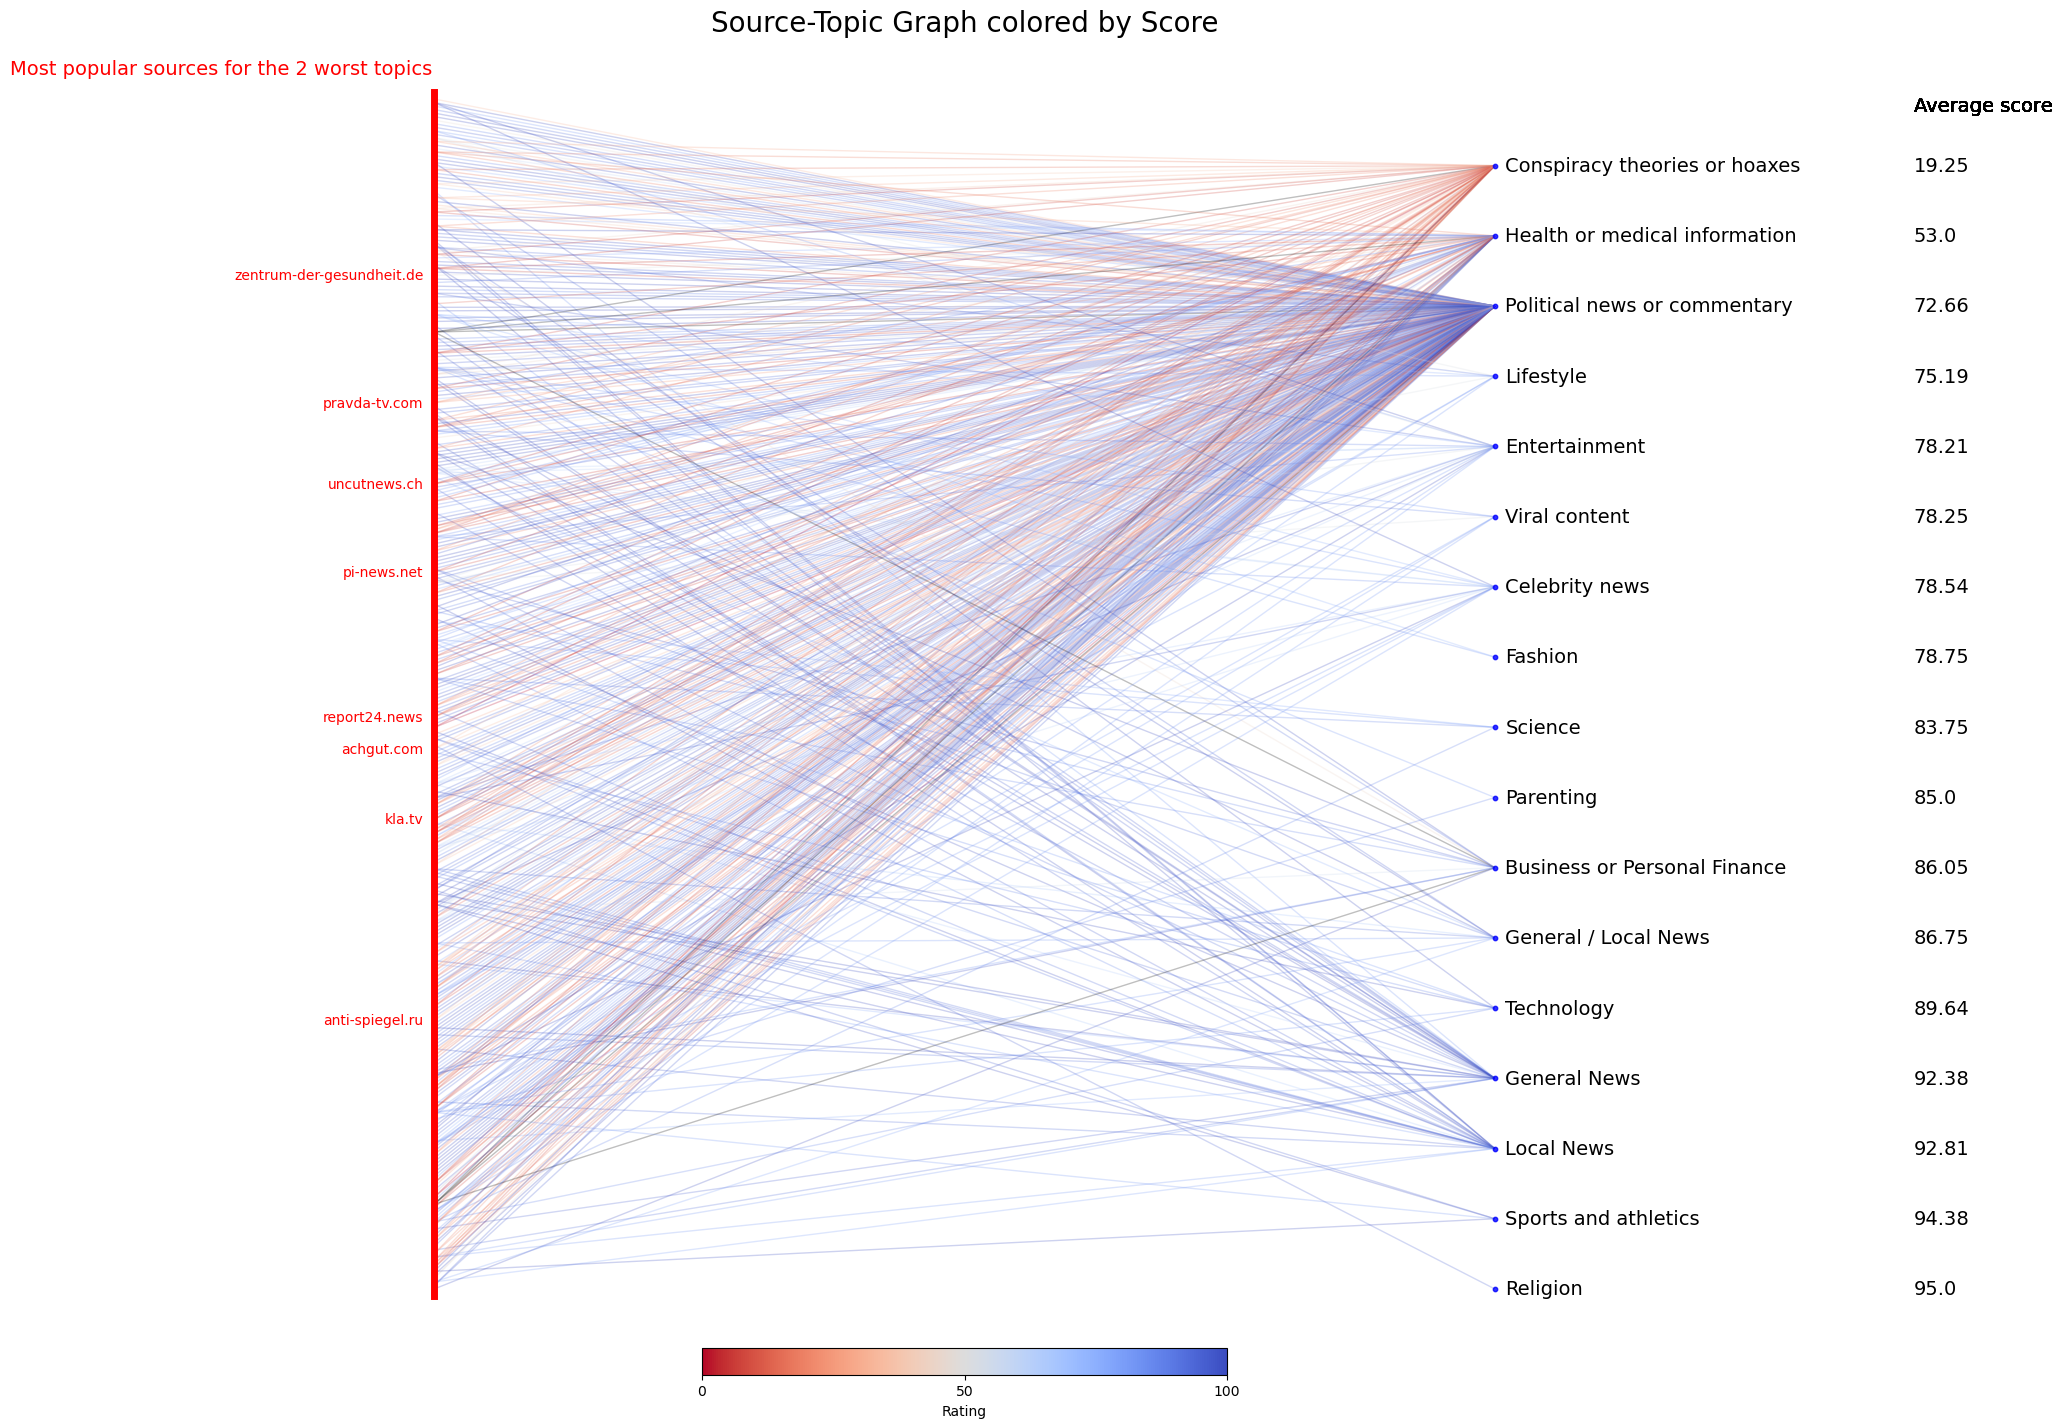

In [55]:
# lets graph this
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

# first we need to get the positions of the nodes, sources on the left and topics on the right
non_source_nodes = [v for v in G.nodes() if G.nodes[v]['type']=='topic']
num_non_source_nodes = len(non_source_nodes)
pos={}
len_sources = len(G.nodes())-num_non_source_nodes
# order the source nodes randomly
random_sources=[node for node in G.nodes() if G.nodes[node]['type']=='source']
random.shuffle(random_sources)

for i,node in enumerate(random_sources):
    if G.nodes[node]['type']=='source':
        pos[node]=(-1,len(G.nodes())/len_sources*i*1.2)
        

# initiate mrk table Topic | avg_score 
table = pd.DataFrame(columns=["Topic","avg_score","Source count"])

# order the topic nodes by the average score of the edges
# first get the average score of the edges
for node in non_source_nodes:
    G.nodes[node]['avg_score'] = np.nanmean([edge[2]['score'] for edge in G.edges(node,data=True)])
    # adding row to markdown table topic | avg_score
    G.nodes[node]['count'] = len([edge[2]['score'] for edge in G.edges(node,data=True)])
    table = pd.concat([table,pd.DataFrame([[node,G.nodes[node]['avg_score'],G.nodes[node]["count"]]],columns=["Topic","avg_score","Source count"])],ignore_index=True)
    
# print the table
display((Markdown(table.to_markdown())))
    

# order the nodes by the average score
non_source_nodes = [node for score,node in sorted([(G.nodes[node]['avg_score'],node) for node in non_source_nodes],reverse=True)]

for i,node in enumerate(non_source_nodes):
    pos[node]=(1,len(G.nodes())/num_non_source_nodes*i*1.2)
        



# lets get the edges and their ratings
# the color of the edge will be the rating

# make a color map that goes from blue to red but reverse it so that red is the lowest rating
cmap = plt.cm.coolwarm.reversed()
 
# get the ratings
ratings = [edge[2]['score'] for edge in G.edges(data=True)]


#big graph
plt.figure(figsize=(10,20))

# plotting the edges with the ratings as colors, using the coolwarm colormap
nx.draw_networkx_edges(G,pos,edge_color=ratings,edge_cmap=cmap,edge_vmin=min(ratings),edge_vmax=max(ratings), alpha=0.25)



# Add a straight line at x=-1 on the left
plt.axvline(x=-1, color='r', alpha=1,ymin=0.04,ymax=0.96, linewidth=5,linestyle='-')
# plot topics
nx.draw_networkx_nodes(G,pos,nodelist=[v for v in G.nodes() if G.nodes[v]['type']=='topic'],node_size=10,node_color='b',alpha=0.8)

# adding labels on the right for the topics

# bump the networkx labels more right by 2 pixels
for _,t in nx.draw_networkx_labels(G,pos,labels={v:v for v in G.nodes() if G.nodes[v]['type']=='topic'},font_size=14, horizontalalignment='left').items():
    t.set_rotation(0)
    t.set_ha('left')
    
    t.set_x(t.get_position()[0]+0.02)
    
    # right to that position add a label with the average score
    
    # get furthermost left position of the node
    
    # assuming you have a text object called t
    
    pos_node = t.get_position()
    pos_node=(pos_node[0]+0.75,pos_node[1])
    node = t.get_text()
    node= G.nodes[node]
    plt.text(pos_node[0]+0.02,pos_node[1],str(round(node['avg_score'],2)),horizontalalignment='left',verticalalignment='center',transform=plt.gca().transData, fontsize=14)
    
    # print on top that this is the average score
    plt.text(pos_node[0]+0.02,len_sources*1.25,"Average score",horizontalalignment='left',verticalalignment='center',transform=plt.gca().transData,fontsize=14)


worse_2_non_sources = [node for score,node in sorted([(G.nodes[node]['avg_score'],node) for node in non_source_nodes],reverse=False)[:2]]

# get top 5 sources by similarweb for each of the 2 worst topics
bad_sources = []
for non_source in worse_2_non_sources:
    bad_sources_nodes=[edge[1] for edge in G.edges(non_source,data=True)]
    # keep only "N" rated nodes
    bad_sources_nodes = [node for node in bad_sources_nodes if G.nodes[node]['rating']=="N"]
    # sort them by similarweb rank
    bad_sources_nodes = sorted(bad_sources_nodes,key=lambda x:G.nodes[x]['ranking'])[:5]
    print(bad_sources_nodes)
    bad_sources.extend(bad_sources_nodes)
    
# add a label for the top 5 sources by ranking, bump it left by 2 pixels
for _,t in nx.draw_networkx_labels(G,pos,labels={v:v for v in bad_sources},font_size=10, horizontalalignment='left', font_color="r").items():
    t.set_rotation(0)
    t.set_ha('right')
    t.set_x(t.get_position()[0]-0.02)

# # get good sources
# good_sources = [v for v in G.nodes() if G.nodes[v]['type']=='source' and G.nodes[v]['rating']=="T"]
# # add a label to the top 5 sources by ranking, bump it left by 2 pixels
# for _,t in nx.draw_networkx_labels(G,pos,labels={v:v for v in sorted(good_sources,key=lambda x:G.nodes[x]['ranking'])[:5]},font_size=10, horizontalalignment='left', font_color="b").items():
#     t.set_rotation(0)
#     t.set_ha('right')
#     t.set_x(t.get_position()[0]-0.02)
    
    
# # get bad sources
# bad_sources = [v for v in G.nodes() if G.nodes[v]['type']=='source' and G.nodes[v]['rating']=="N"]

# add a label to the top 5 bad sources by ranking, bump it left by 2 pixels
# for _,t in nx.draw_networkx_labels(G,pos,labels={v:v for v in sorted(bad_sources,key=lambda x:G.nodes[x]['ranking'])[:5]},font_size=10, horizontalalignment='left', font_color="r").items():
#     t.set_rotation(0)
#     t.set_ha('right')
#     t.set_x(t.get_position()[0]-0.02)
    
    
    



plt.axis('off')
# adding the cmap as a colorbar, at the bottom
cbar=plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap),label='Rating',orientation='horizontal',shrink=0.3,pad=0)
cbar.set_ticks([0,0.5,1])
cbar.set_ticklabels(['0',"50",'100'])

plt.margins(x=0.25, y=0)
plt.subplots_adjust(right=1.75, left=0)
plt.title("Source-Topic Graph colored by Score", fontsize=20)
ymax=plt.ylim()[1]

plt.text(-1.80,ymax*0.95+10, "Most popular sources for the 2 worst topics", fontsize=14, color="r")

# # add a legend on the top left saying "Top 5 Good Sources" and "Top 5 Bad Sources"
# plt.text(-1.5,plt.ylim()[1]*0.95+10, "Top 5 Good Sources", fontsize=14, color="b")
# plt.text(-1.5,plt.ylim()[1]*0.95, "Top 5 Bad Sources", fontsize=14, color="r")
# saving graph in hq
plt.savefig('source_topic_graph.png', dpi=300, bbox_inches='tight')

plt.show()


In [56]:
# make a df with the sources, their attributes and the topics they are connected to
source_df = pd.DataFrame(columns=["Source","Rating","Score","Ranking","Topics"])
source_df["Source"] = [v for v in G.nodes() if G.nodes[v]['type']=='source']
source_df["Score"] = [G.nodes[v]['score'] for v in G.nodes() if G.nodes[v]['type']=='source']
source_df["Rating"] = [G.nodes[v]['rating'] for v in G.nodes() if G.nodes[v]['type']=='source']
source_df["Ranking"] = [G.nodes[v]['ranking'] for v in G.nodes() if G.nodes[v]['type']=='source']
source_df["Topics"] = [[edge[1] for edge in G.edges(v) if G.nodes[edge[1]]['type']=='topic'] for v in G.nodes() if G.nodes[v]['type']=='source']

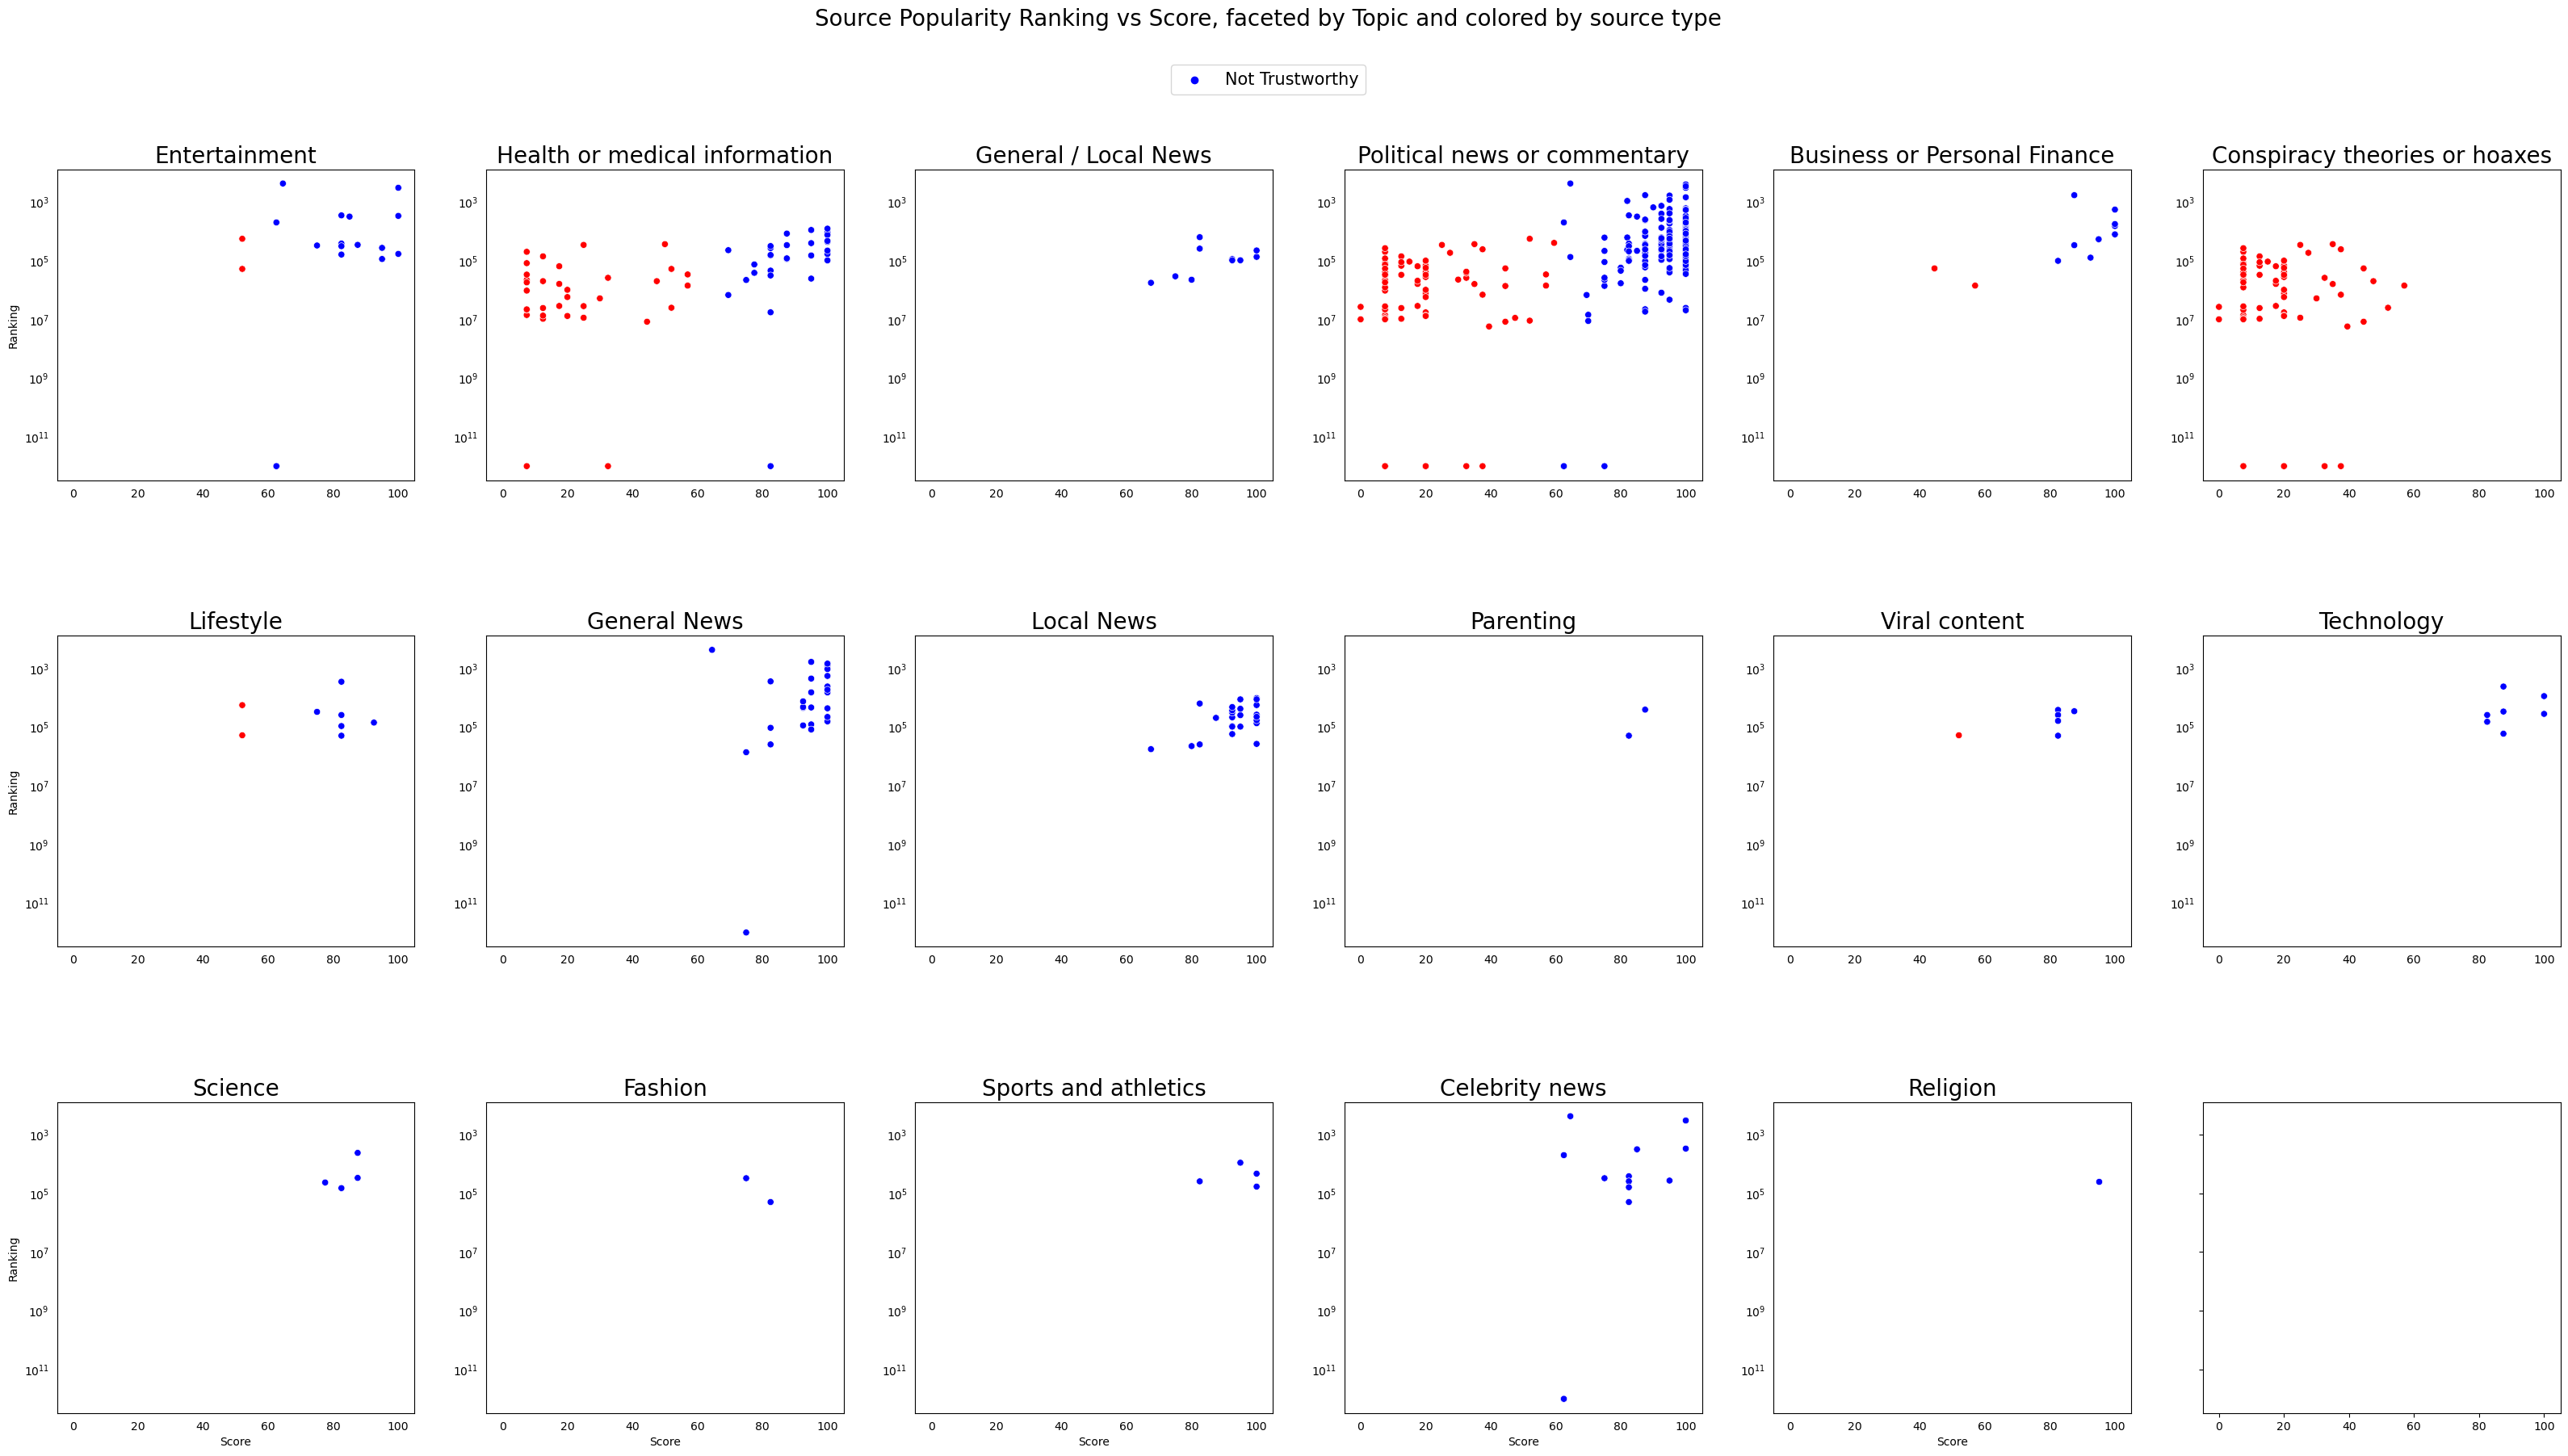

In [57]:
# faceted plot log ranking by score, facted by topic
import seaborn as sns
import matplotlib
topics=set([topic for sublist in source_df["Topics"] for topic in sublist])
lent= len(topics)
fig, axs = plt.subplots(3,6,figsize=(40,20),sharey=True, sharex=True,)
# make it show the ticks labels everywhere despite sharing it

# make every subplot taller
fig.subplots_adjust(hspace=0.5)
for topic in topics:
    topic_df = source_df[source_df["Topics"].apply(lambda x: topic in x)]
    # get the axes for this topic
    ax=axs.flatten()[list(topics).index(topic)]
    
    # dictionary for hues T is blue, N is red
    hues={"T":"b","N":"r","P":"w"}

    # plot the scatterplot, use the hues dict for the colot
    sns.scatterplot(data=topic_df, x="Score", y="Ranking", hue="Rating", palette=hues, ax=ax)
    ax.set_title(topic)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="both", bottom=False, top=False, labelbottom=True, left=False, right=False, labelleft=True)
    # turn off legend
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    
    # make subplot title bigger
    ax.title.set_size(20)

fig.suptitle("Source Popularity Ranking vs Score, faceted by Topic and colored by source type", fontsize=20)
# make a global legend, with the color of the Rating
fig.legend(labels=["Not Trustworthy","Trustworthy"], loc='upper center', ncol=2, fontsize=15, handles=handles, bbox_to_anchor=(0.5, 0.95))

# substitute T and N with Trastworthy and Not Trustworthy in the legneds

plt.show()


In [58]:
# group by topic and get the top 5 sources by ranking for each rating
for topic in topics:
    topic_df = source_df[source_df["Topics"].apply(lambda x: topic in x)]
    topic_df = topic_df.sort_values("Ranking")[["Source","Ranking","Score","Rating"]]
    top_5_pos=topic_df[topic_df["Rating"]=="T"].head(5)
    top_5_neg=topic_df[topic_df["Rating"]=="N"].head(5)
    display(Markdown("### Most popular positive sources for Topic: "+topic))
    display(Markdown(top_5_pos.to_markdown()))
    display(Markdown("### Most popular negative sources for Topic: "+topic))
    display(Markdown(top_5_neg.to_markdown()))
    
    

### Most popular positive sources for Topic: Entertainment

|     | Source       |   Ranking |   Score | Rating   |
|----:|:-------------|----------:|--------:|:---------|
|  53 | bild.de      |       235 |    64.5 | T        |
| 212 | gmx.net      |       329 |   100   | T        |
| 329 | vice.com     |      2864 |    82.5 | T        |
|  92 | tz.de        |      2983 |   100   | T        |
| 300 | derwesten.de |      3151 |    85   | T        |

### Most popular negative sources for Topic: Entertainment

|     | Source       |   Ranking |   Score | Rating   |
|----:|:-------------|----------:|--------:|:---------|
| 227 | servustv.com |     17954 |      52 | N        |
| 225 | heftig.de    |    191154 |      52 | N        |

### Most popular positive sources for Topic: Health or medical information

...

| Source   | Ranking   | Score   | Rating   |
|----------|-----------|---------|----------|

### Most popular positive sources for Topic: Religion

|    | Source        |   Ranking |   Score | Rating   |
|---:|:--------------|----------:|--------:|:---------|
| 32 | katholisch.de |     39391 |      95 | T        |

### Most popular negative sources for Topic: Religion

| Source   | Ranking   | Score   | Rating   |
|----------|-----------|---------|----------|

# Orientation

Let's see what does the political orientation tells us

In [59]:
df_de.Orientation.value_counts()

Orientation
Far Right         204
Slightly Left     194
Slightly Right    118
Right              57
Far Left           54
Left               14
Name: count, dtype: int64

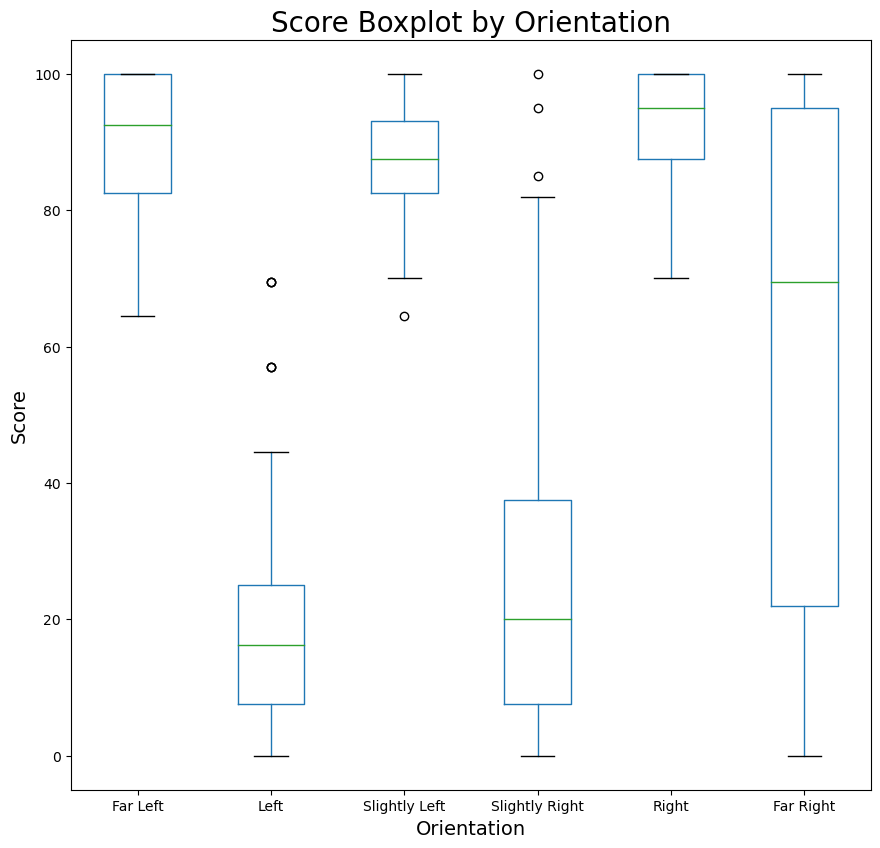

In [60]:
# score boxplot by orientation
df_de.boxplot(column="Score",by="Orientation",figsize=(10,10))

plt.title("Score Boxplot by Orientation", fontsize=20)
plt.suptitle("")
plt.xlabel("Orientation", fontsize=14)
plt.xticks([1,2,3,4,5,6],['Far Left','Left','Slightly Left','Slightly Right','Right','Far Right'],rotation=0)
plt.ylabel("Score", fontsize=14)
# remove grid
plt.grid(False)


Let's see a violinplot to see the distribution as well

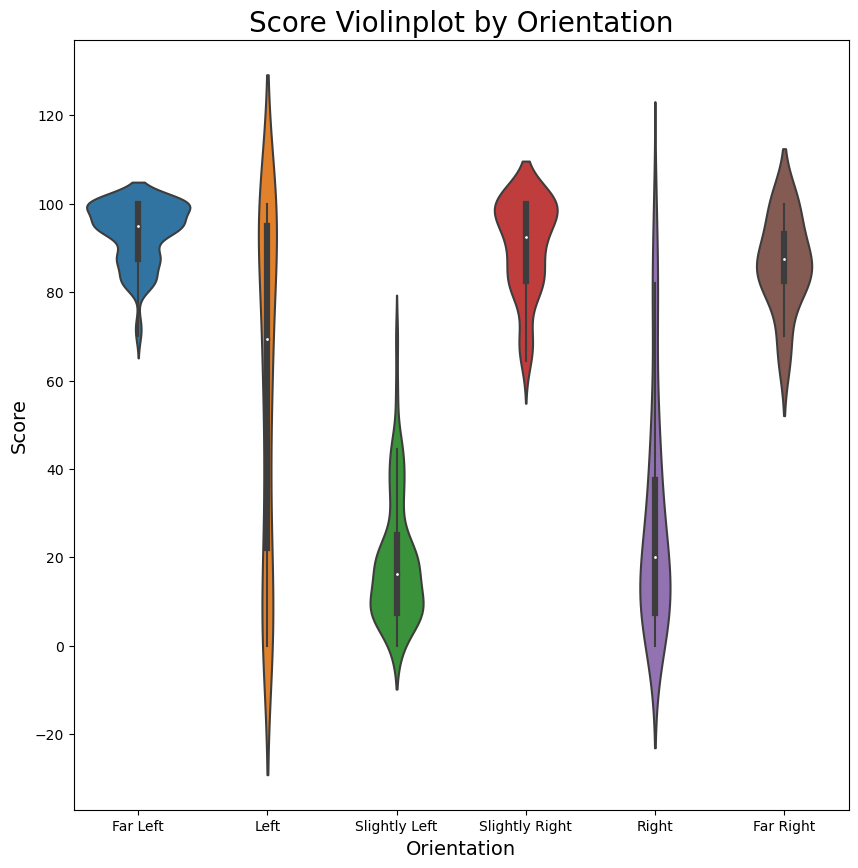

In [61]:
# make a violinpolt of the score by orientation
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,10))
sns.violinplot(x="Orientation", y="Score", data=df_de, ax=ax)
ax.set_title("Score Violinplot by Orientation", fontsize=20)
ax.set_xlabel("Orientation", fontsize=14)
ax.set_xticklabels(['Far Left','Left','Slightly Left','Slightly Right','Right','Far Right'],rotation=0)
ax.set_ylabel("Score", fontsize=14)
plt.show()

C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\3213705409.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_de['Orientation'] = df_de['Orientation'].replace({'Far Left':-1,'Slightly Left':-0.25,'Left':-0.5,'Center':0,'Right':0.5,'Slightly Right':0.25,'Far Right':1})


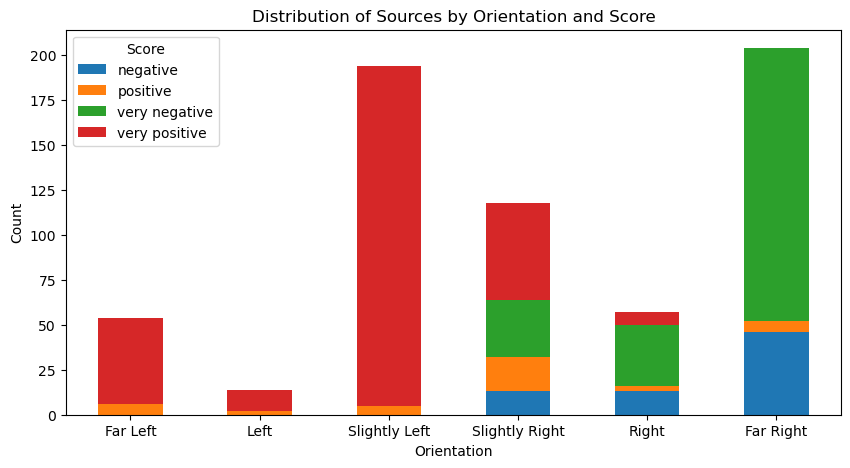

In [62]:


# make Orientation be a scale that goes from Far Left to Far right
df_de['Orientation'] = df_de['Orientation'].replace({'Far Left':-1,'Slightly Left':-0.25,'Left':-0.5,'Center':0,'Right':0.5,'Slightly Right':0.25,'Far Right':1})
# plot counts per orientation category, colored by score (group by score_cat), for the first date of the dataset
df_de.groupby(['Orientation','score_cat']).size().unstack().plot(kind='bar',stacked=True,figsize=(10,5))

# put the labels on the bars
plt.xticks([0,1,2,3,4,5],['Far Left','Left','Slightly Left','Slightly Right','Right','Far Right'],rotation=0)
plt.ylabel("Count")
plt.title("Distribution of Sources by Orientation and Score")

# set the legend title
plt.legend(title="Score")


plt.show()

Those plots are misleading, because they treat the aggregate data over the years, repeating the same sources/spanning different categorization methods. Let's see how the categorization changed over the years

C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\292548668.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_de.Orientation.replace({-1:'Far Left',-0.25:'Slightly Left',-0.5:'Left',0.5:'Right',0.25:'Slightly Right',1:'Far Right'},inplace=True)
C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\292548668.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_de.Orientation = pd.Categorical(df_de.Orientation, categories=['Far Left','Left','Slightly Left','Slightly Right','Right','Far Right'], ordered=True)
C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\2925

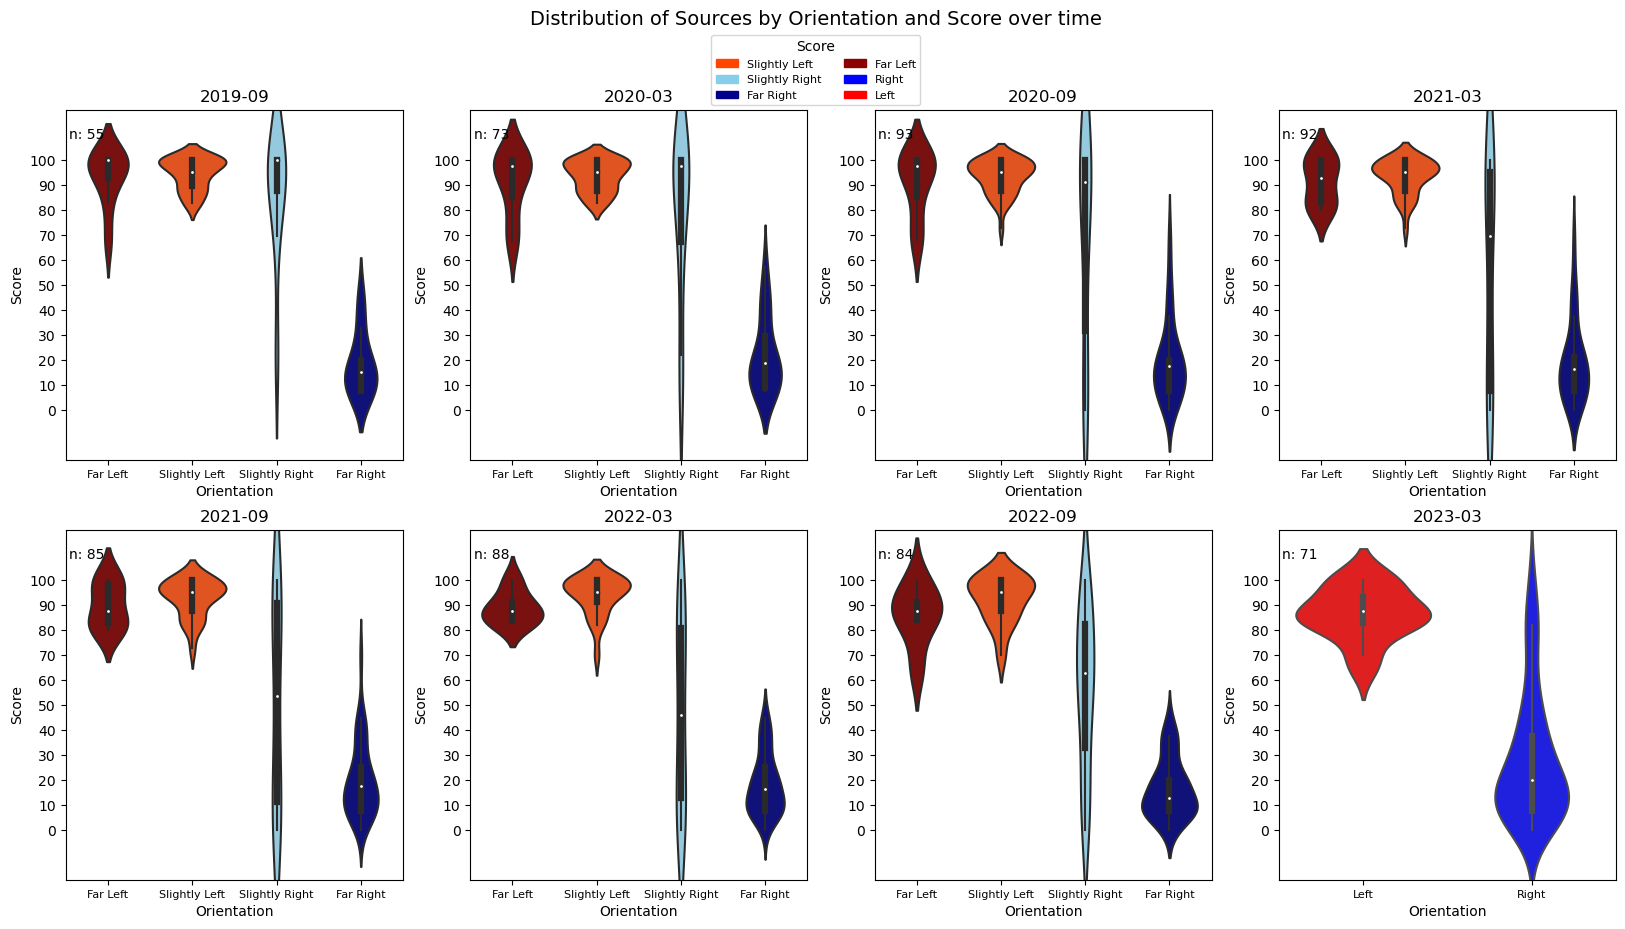

In [63]:
df_de.Orientation.replace({-1:'Far Left',-0.25:'Slightly Left',-0.5:'Left',0.5:'Right',0.25:'Slightly Right',1:'Far Right'},inplace=True)
# make orientation an ordered categorical variable
df_de.Orientation = pd.Categorical(df_de.Orientation, categories=['Far Left','Left','Slightly Left','Slightly Right','Right','Far Right'], ordered=True)

# make a tall fig with 8 subplots
fig, axs=plt.subplots(2,4,figsize=(80, 80), sharey=False)

# left red, far left dark red slightly left orange, slightly right sky blue, slightly right blue, right black
colors={"Left":"r","Far Left":"darkred","Slightly Left":"orangered","Slightly Right":"skyblue","Right":"b","Far Right":"darkblue","Undefined":"gray"}
# for each date, print the number of sources per orientation
for date in df_de.file_date.unique():
    df_date=df_de[df_de.file_date==date] 
    df_date.Orientation=df_date.Orientation.cat.add_categories("Undefined")
    df_date.Orientation.fillna("Undefined",inplace=True)
    # get ax 
    ax=axs.flatten()[list(df_de.file_date.unique()).index(date)]
    # drop undefined
    df_date=df_date[df_date.Orientation!="Undefined"]
    # remove categories with no data
    df_date.Orientation=df_date.Orientation.cat.remove_unused_categories()
    
    # plot the violin plot grouping by orientation 
    sns.violinplot(x="Orientation", y="Score", data=df_date, ax=ax, palette=colors)
    # formatted date as title
    axs.flatten()[list(df_de.file_date.unique()).index(date)].set_title(date.strftime("%Y-%m"))
    # get handles and disable legend
    axs.flatten()[list(df_de.file_date.unique()).index(date)].legend().set_visible(False)
    
    # delete all the ticks that are not between 0 and 100
    ax.set_yticks(np.arange(0, 101, 10))

    # add padding to the top of the plot
    ax.margins(y=0.001)
    ax.set_ylim(-20,120 )
    
    
    #handles, labels = axs.flatten()[list(df_de.file_date.unique()).index(date)].get_legend_handles_labels()
    
    # ticks on the x axis horizontal and smaller
    axs.flatten()[list(df_de.file_date.unique()).index(date)].tick_params(axis="x", rotation=0, labelsize=8)
    # make subplot more spaced
    axs.flatten()[list(df_de.file_date.unique()).index(date)].margins(y=0.1)
    # print on the up left of the plot the number of sources
    axs.flatten()[list(df_de.file_date.unique()).index(date)].text(0.01, 0.95, "n: "+str(len(df_date.loc[df_date.Orientation.notna(),])),verticalalignment='top', horizontalalignment='left', transform=axs.flatten()[list(df_de.file_date.unique()).index(date)].transAxes, fontsize=10)
    
    
# title
fig.suptitle("Distribution of Sources by Orientation and Score over time", fontsize=14)


# make a legend from all the colors
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in df_de.Orientation.unique().dropna()]
labels = df_de.Orientation.unique().dropna()
fig.legend(title="Score", handles=handles, labels=labels, loc='upper center', ncol=2, fontsize=8, bbox_to_anchor=(0.5, 0.96))



# more vertical space between subplots
axs.flatten()[0].margins(y=1)

fig.set_figheight(10)
fig.set_figwidth(20)
fig.savefig("violinplot_orientation.png", dpi=300, bbox_inches='tight')
plt.show()


So, in the last year they are using only this Left/Right distinction, nevertheless, the phenomenon of left wing getting better scores endures

Apparently, right wing leaning sources tend to get lower scores. I propose two possible explanations:
1. Bias by the rating agency (could be a bit but I think it's unlikely to explain this contrast)
2. As an American comedian once said, "Reality has a well known liberal bias"

Let's see how does orientation work in the latest df

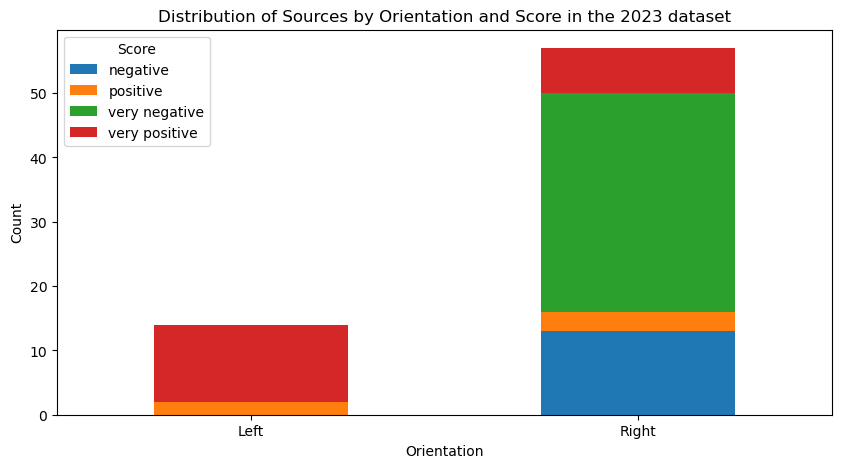

In [64]:
df_de_last["Orientation"]=df_de_last["Orientation"].replace({"Left":-1,"Right":1})
df_de_last.replace({-1:"Left",1:"Right"},inplace=True)
df_de_last['Orientation'] =pd.Categorical(df_de_last['Orientation'], categories=['Left','Right'], ordered=True)
df_de_last.groupby(['Orientation','score_cat']).size().unstack().plot(kind='bar',stacked=True,figsize=(10,5))

# put the labels on the bars
plt.xticks([0,1],['Left','Right'],rotation=0)
plt.ylabel("Count")
plt.title("Distribution of Sources by Orientation and Score in the 2023 dataset")

# set the legend title
plt.legend(title="Score")


plt.show()

More simplistic but still the same result - left wing sources tend to be more reliable

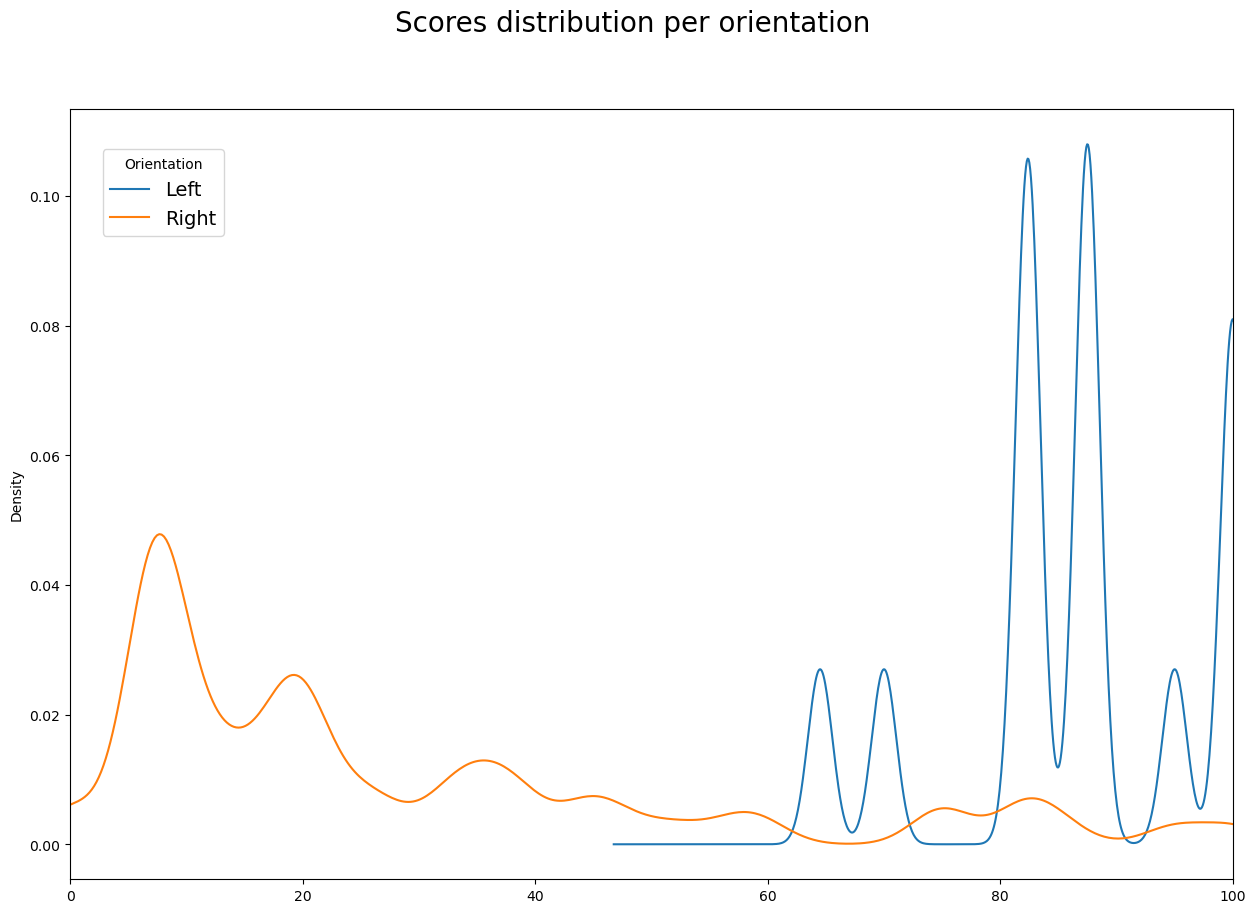

In [65]:
# kdi density plot of the score by orientation
df_de_last=df_de_last[df_de_last.Score.notna()]
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Scores distribution per orientation', fontsize=20)
for orientation in ["Left","Right"]:
    # density plot that starts from 0 and ends at 100
    df_de_last[df_de_last.Orientation==orientation].Score.plot.kde(ax=ax, xlim=(0,100), label=orientation, bw_method=0.1)
    

# put a legend inside the axes on the upper left
fig.legend(loc="upper left", title="Orientation", bbox_to_anchor=(0.14, 0.85), fontsize=14)


In [66]:
df_de_last.Orientation.unique()

[NaN, 'Right', 'Left']
Categories (2, object): ['Left' < 'Right']

In [67]:
df_de_last.groupby(['Score','Orientation']).value_counts()

Series([], Name: count, dtype: int64)

# Topic - Orientation interaction

Let's see if something can be said about the distribution of sources of various orientations between topics 

In [68]:
source_df["Orientation"] = source_df["Source"].apply(lambda x: df_de_last[df_de_last["Domain"]==x]["Orientation"].values[0] if x in df_de_last["Domain"].values else None)

In [69]:
source_df.Orientation.value_counts()

Orientation
Right    57
Left     14
Name: count, dtype: int64

In [70]:
source_df.columns

Index(['Source', 'Rating', 'Score', 'Ranking', 'Topics', 'Orientation'], dtype='object')

In [71]:
# drop sources without scores 
source_df.dropna(subset=["Score"],inplace=True)

We don't many sources or political leaning nuance in this latest dataset, but we can still see how they relate to topics

In [72]:
17*2*5

170

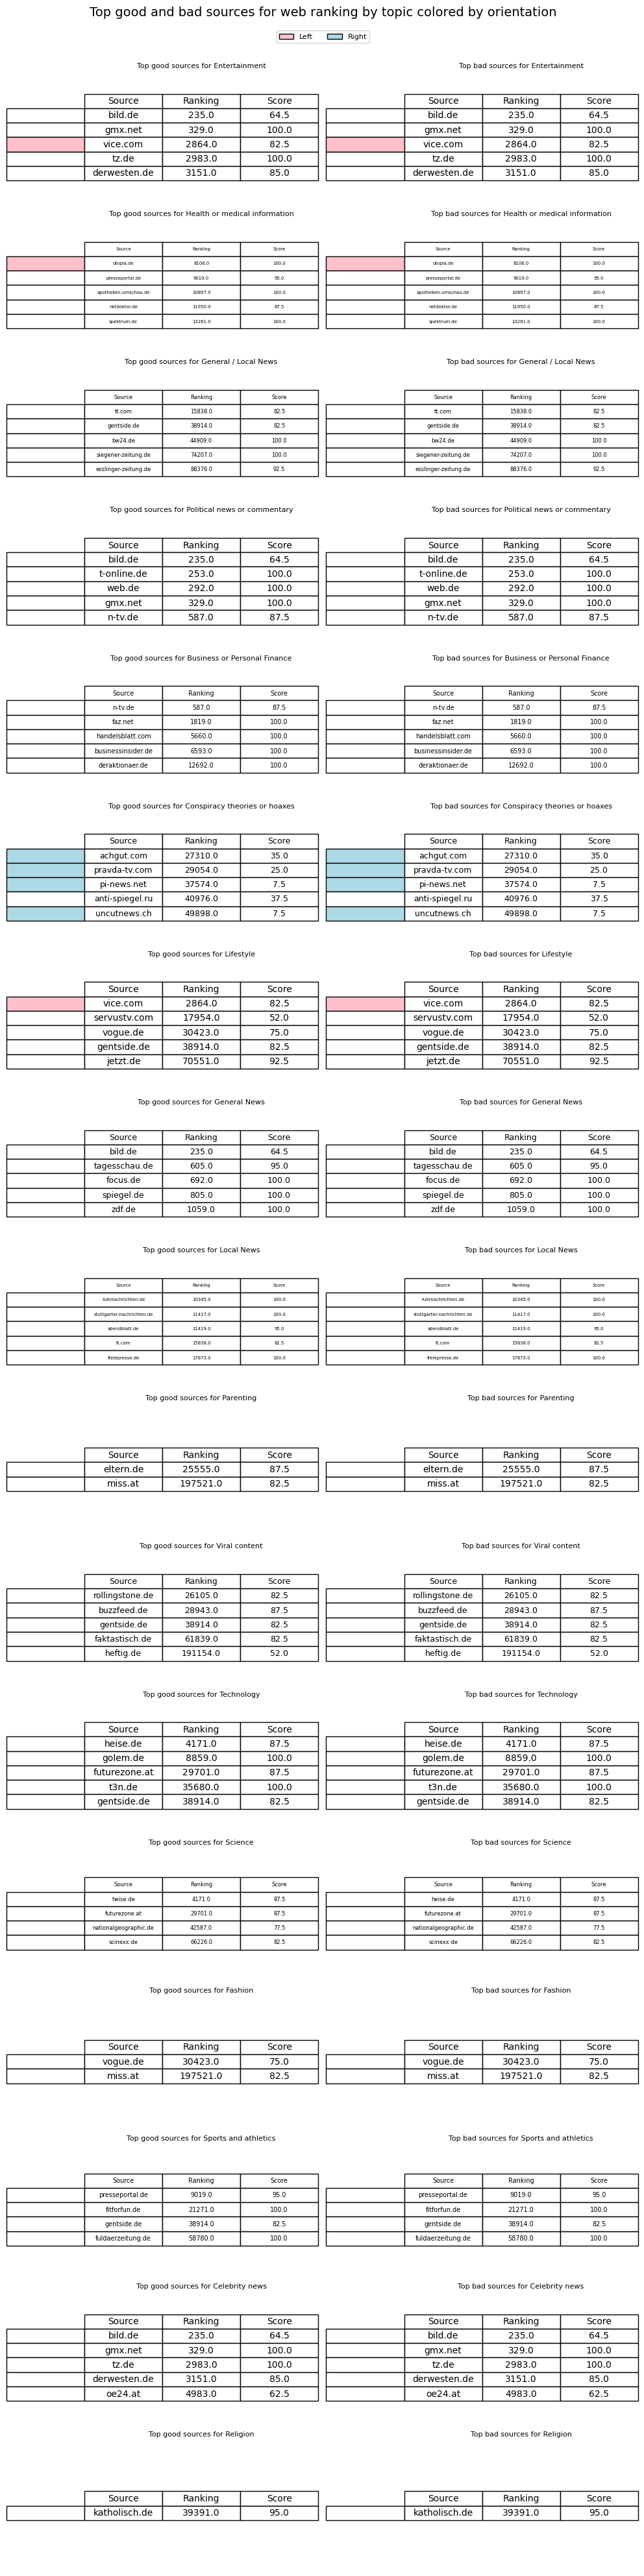

In [73]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
#import patch
from matplotlib.patches import Patch

# make a faced table plot of top goood and bad sources by similar_ranking by topic colored by orientation
fig = plt.figure(figsize=(10, 80))
gs = gridspec.GridSpec(nrows=35, ncols=2, figure=fig)
newi=0
for ie, topic in enumerate(topics):
    # df of rows where topic is in the list of topics
    df_topic = source_df[source_df["Topics"].apply(lambda x: topic in x)]
    
    # make a table of top 5 good and bad sources by similar_ranking
    df_topic_good = df_topic.sort_values(by="Ranking",ascending=True).head(5)
    df_topic_good.Orientation=df_topic_good.Orientation.apply(str)
    
    # plot a table, color by orientation
    colors = [(255/255, 255/255, 255/255, 1) for i in range(len(df_topic_good))]
    for i in range(len(df_topic_good)):
        if df_topic_good.iloc[i]['Orientation'] == 'Left':
            colors[i] = (255/255, 192/255, 203/255, 1)
        elif df_topic_good.iloc[i]['Orientation'] == 'Right':
            colors[i] = (173/255, 216/255, 230/255, 1)
    
    ax1 = fig.add_subplot(gs[newi])
    ax1.table(cellText=df_topic_good[["Source","Ranking","Score"]].values, colLabels=["Source","Ranking","Score"], loc='center',cellLoc='center',rowColours=colors)
    ax1.axis('off')
    ax1.set_title(f"Top good sources for {topic}",fontsize=8)
    
    df_topic_bad = df_topic.sort_values(by="Ranking",ascending=True).head(5)
    df_topic_bad.Orientation=df_topic_bad.Orientation.apply(str)
    
    colors = [(255/255, 255/255, 255/255, 1) for i in range(len(df_topic_bad))]
    for i in range(len(df_topic_bad)):
        if df_topic_bad.iloc[i]['Orientation'] == 'Left':
            colors[i] = (255/255, 192/255, 203/255, 1)
        elif df_topic_bad.iloc[i]['Orientation'] == 'Right':
            colors[i] = (173/255, 216/255, 230/255, 1)
    
    ax2 = fig.add_subplot(gs[newi+1])
    ax2.table(cellText=df_topic_bad[["Source","Ranking","Score"]].values, colLabels=["Source","Ranking","Score"], loc='center',cellLoc='center',rowColours=colors)
    ax2.axis('off')
    ax2.set_title(f"Top bad sources for {topic}",fontsize=8)
    newi=newi+2
    ax1.margins(y=0.1,x=0.1)
    ax2.margins(y=0.1,x=0.1)
    
    # squeeze the table to not fill all the subplot space
    ax1.set_xmargin(1.1)

fig.tight_layout()
# set title
fig.suptitle("Top good and bad sources for web ranking by topic colored by orientation", fontsize=14, position=(0.5,1.009))
legend_elements = [Patch(facecolor=(255/255, 192/255, 203/255, 1), edgecolor='black', label='Left'),Patch(facecolor=(173/255, 216/255, 230/255, 1), edgecolor='black', label='Right')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=8, bbox_to_anchor=(0.5, 1.005))
plt.show()


Apparently, some of the top sources for most topics do not have an orientation score in the dataset

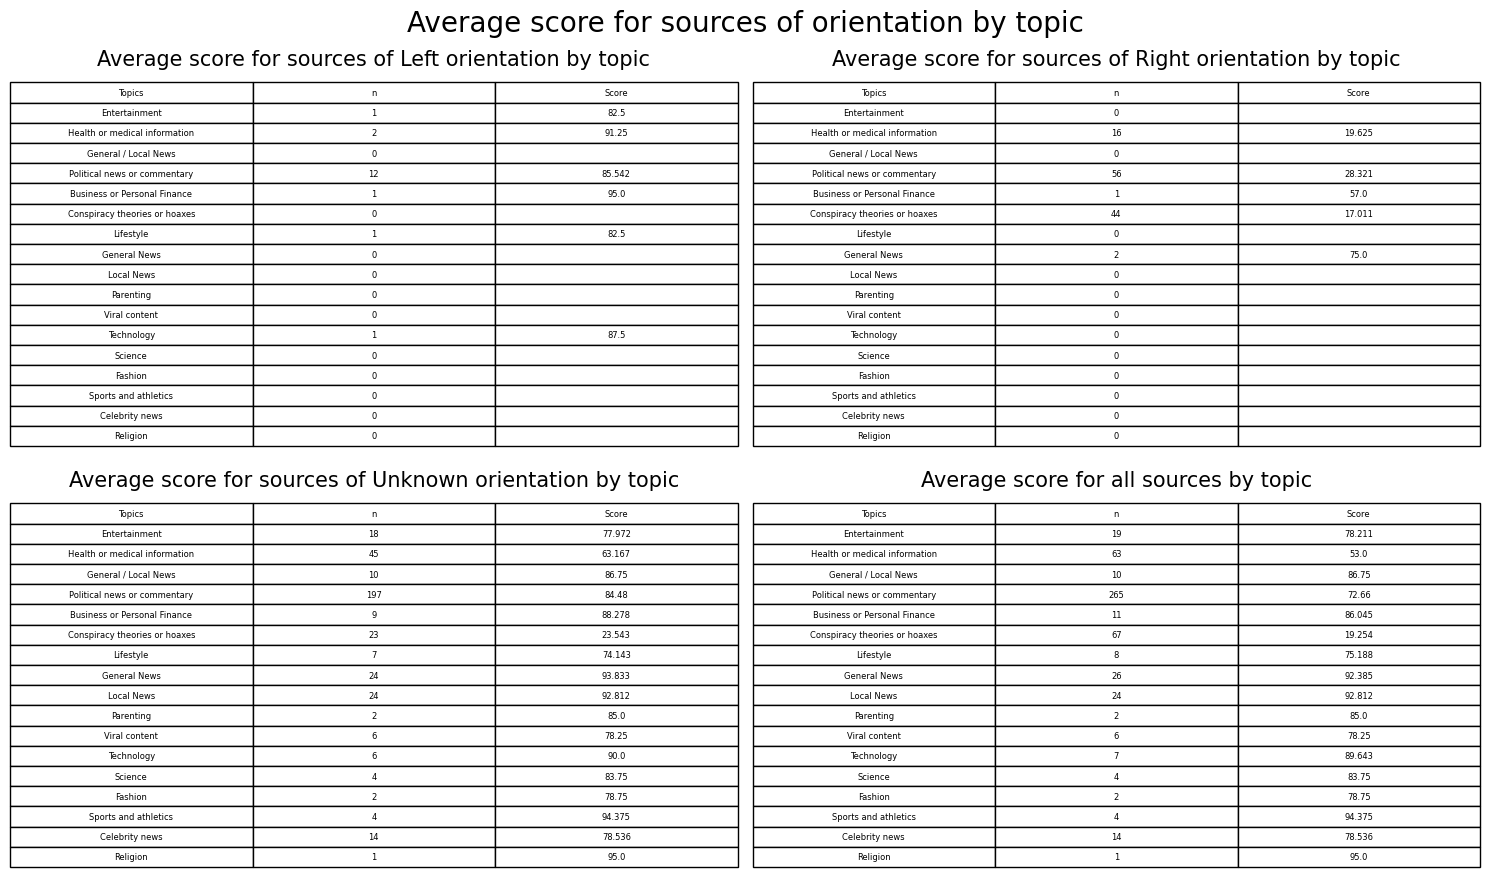

In [74]:
# table with averages of scores by orientation and topic
fig, axs = plt.subplots(2,2,figsize=(15, 9))

#substitutee nan with unknown
source_df = source_df[["Orientation","Score","Topics"]].fillna("Unknown")
for orientation in source_df.Orientation.unique():
    orientation_df = source_df[source_df["Orientation"]==orientation]
    # get ax
    ax= axs[0,0] if orientation=="Left" else axs[0,1] if orientation=="Right" else axs[1,0] if orientation=="Unknown" else axs[1,1]
    df = pd.DataFrame(columns=["Topics","n","Score"])
    for topic in topics:
        orientation_topic_df = orientation_df[orientation_df["Topics"].apply(lambda x: topic in x)]
        mean_score = orientation_topic_df["Score"].mean()
        mean_score = round(mean_score,3) if not np.isnan(mean_score) else ""
        n=len(orientation_topic_df)
        df= pd.concat([df,pd.DataFrame([[topic,n,mean_score]],columns=["Topics","n","Score"])])
    ax.table(cellText=df.values, colLabels=["Topics","n","Score"], loc='center',cellLoc='center')
    ax.title.set_text(f"Average score for sources of {orientation} orientation by topic")
    # turn off axis
    ax.axis('off')
    # reduce margins
    ax.margins(y=0.1,x=0.1)
    ax.title.set_fontsize(15)
ax= axs[1,1]
df= pd.DataFrame(columns=["Topics","n","Score"])
for topic in topics:
    topics_df = source_df[source_df["Topics"].apply(lambda x: topic in x)]
    mean_score = topics_df["Score"].mean()
    mean_score = round(mean_score,3) if not np.isnan(mean_score) else ""
    n=len(topics_df)
    df= pd.concat([df,pd.DataFrame([[topic,n,mean_score]],columns=["Topics","n","Score"])])
    
ax.title.set_text(f"Average score for all sources by topic")
# turn off axis
ax.axis('off')
# reduce margins
ax.margins(y=0.4,x=0.1)
ax.title.set_fontsize(15)
ax.table(cellText=df.values, colLabels=["Topics","n","Score"], loc='center',cellLoc='center')
fig.suptitle("Average score for sources of orientation by topic", fontsize=20)
fig.tight_layout()
    

        

## Checking other languages

In [75]:
df_total_last=df_total[df_total["file_date"]==df_total["file_date"].max()]

df_total_last

,UUID,Domain,Parent Domain,Rating,Score,Last Updated,Country,Language,Does not repeatedly publish false content,Gathers and presents information responsibly,...,myths,iOS App,Android App,Original Reporting,Targeted Audience,Contact Mail Form URL.1,Other,False Narratives,Communities Served,BrandGuard Segments
0,4bcfdfb8-5587-4b00-a7c4-c4d46d31bc3a,al.com,NaN,T,95.0,1677645622005,US,en,Yes,Yes,...,NaN,https://apps.apple.com/us/app/al-com/id419876008,https://play.google.com/store/apps/details?id=...,Yes,"Regional,Local",NaN,https://www.pinterest.com/aldotcom/,NaN,NaN,"Inclusion - Maximum Safety,Inclusion - High Sa..."
1,c6f74984-caa8-4d25-b0ab-dcd42d60d077,jacobinmag.com,jacobin.com,T,92.5,1677642090547,US,en,Yes,Yes,...,NaN,NaN,NaN,Yes,International,NaN,NaN,NaN,NaN,"Inclusion - High Safety,Inclusion - Basic Safe..."
2,a24182b5-9944-43bc-917f-18db87d2f129,jacobin.com,jacobin.com,T,92.5,1677642090426,US,en,Yes,Yes,...,NaN,NaN,NaN,Yes,International,NaN,NaN,NaN,NaN,"Inclusion - High Safety,Inclusion - Basic Safe..."
3,4e2555e2-2abf-4635-ba5c-8c42a706fa9d,bizpacreview.com,NaN,T,62.0,1677641633936,US,en,Yes,No,...,NaN,NaN,NaN,Yes,National,NaN,NaN,"7c0c4118-c60a-4887-a53b-83371d7a0d25,15ab8d62-...",NaN,"Inclusion - Basic Safety,Exclusion - Maximum S..."
4,e67b8cbe-7ca6-4d0f-b12d-ba25af9b726b,americanwirenews.com,NaN,T,74.5,1677641172988,US,en,Yes,No,...,NaN,NaN,NaN,NaN,National,NaN,NaN,"15ab8d62-3d32-4c9a-8cbd-56dd466fa2f4,e443b42d-...",NaN,"Inclusion - Basic Safety,Exclusion - Maximum S..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9921,5b442eb2-eb14-4cf0-b6ff-c81679685b0f,gesundheitstrends.com,NaN,T,82.5,1616835161457,DE,de,Yes,Yes,...,NaN,NaN,NaN,Yes,"National,International",NaN,NaN,NaN,NaN,"Inclusion - High Safety,Inclusion - Basic Safe..."
9922,40fb1140-536a-47a0-a06c-023fbc3ddc07,flinkfeed.com,NaN,N,39.5,1615380820284,ALL,en,Yes,No,...,NaN,NaN,NaN,NaN,National,NaN,NaN,NaN,NaN,"Exclusion - Maximum Safety,Exclusion - High Sa..."
9923,ae8b500d-683f-4e3d-a4a2-260b725ae142,flinkfeed.com,NaN,N,39.5,1615380816262,DE,de,Yes,No,...,NaN,NaN,NaN,NaN,National,NaN,NaN,NaN,NaN,"Exclusion - Maximum Safety,Exclusion - High Sa..."
9924,38ffb203-ebe5-4cac-8b5a-f84dd3697faf,blog.halle-leaks.de,NaN,N,37.5,1611208307207,DE,de,No,No,...,NaN,NaN,NaN,NaN,"Regional,National",NaN,NaN,NaN,NaN,"Exclusion - Maximum Safety,Exclusion - High Sa..."


In [76]:
df_total_last.shape

(9926, 55)

In [77]:
for language in df_total_last.Language.unique():
    # print average score by language
    unique_sources = df_total_last[df_total_last["Language"]==language]["Domain"].unique()
    print(f"Language: {language}, Average: {df_total_last[df_total_last['Language']==language]['Score'].mean()}, Number of sources: {unique_sources.shape[0]}")

Language: en, Average: 63.592234141791046, Number of sources: 8663
Language: it, Average: 71.71670190274841, Number of sources: 481
Language: fr, Average: 66.00477326968974, Number of sources: 431
Language: de, Average: 75.1125730994152, Number of sources: 347
Language: es, Average: 82.5, Number of sources: 1


## DE, IT and EN dataset

In [78]:
# get it language, de language and en language sources
dataset=df_total[df_total_last["Language"].isin(["it","de","en"])]
dataset=dataset[dataset.Country.isin(["US","IT","DE","GB","AT"])]



C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\1609805973.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dataset=df_total[df_total_last["Language"].isin(["it","de","en"])]


In [79]:
# score over years
dataset["file_date"]=pd.to_datetime(dataset["file_date"])

In [80]:
dataset.groupby(["file_date"]).Score.mean()
dataset.groupby(["file_date"]).Score.median()


file_date
2019-03-01    87.5
2019-09-01    87.5
2020-03-01    82.5
2020-09-01    77.5
2021-03-01    80.0
2021-09-01    77.5
2022-03-01    80.0
2022-09-01    80.0
2023-03-01    72.5
Name: Score, dtype: float64

In [81]:
df_total_last[~df_total_last["Language"].isin(["it","de","en"])].Language.value_counts()

Language
fr    431
es      1
Name: count, dtype: int64

In [82]:
dataset.Language.value_counts()

Language
en    43130
it     2616
de     2027
es        2
Name: count, dtype: int64

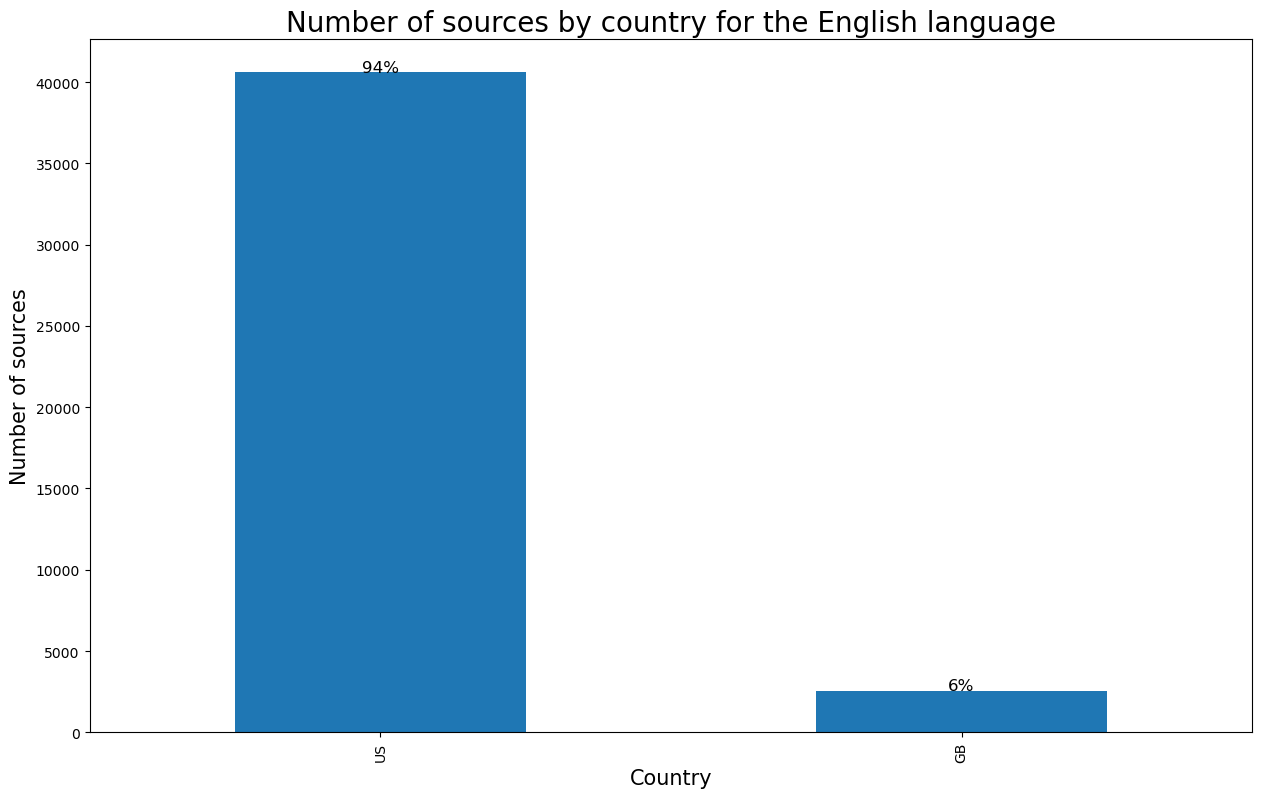

In [83]:
# plot en language sources by country

# bar plot with number of sources by country

plt.figure(figsize=(15, 9))
dataset[dataset["Language"]=="en"].Country.value_counts().plot(kind="bar")
# plot over every bar the percentage of sources

for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x()+p.get_width()/2,height+50, '{:.0f}%'.format(height/dataset[dataset["Language"]=="en"].shape[0]*100), ha="center",fontsize=12)
    


plt.title("Number of sources by country for the English language",fontsize=20)
plt.xlabel("Country",fontsize=15)
plt.ylabel("Number of sources",fontsize=15)
plt.show()

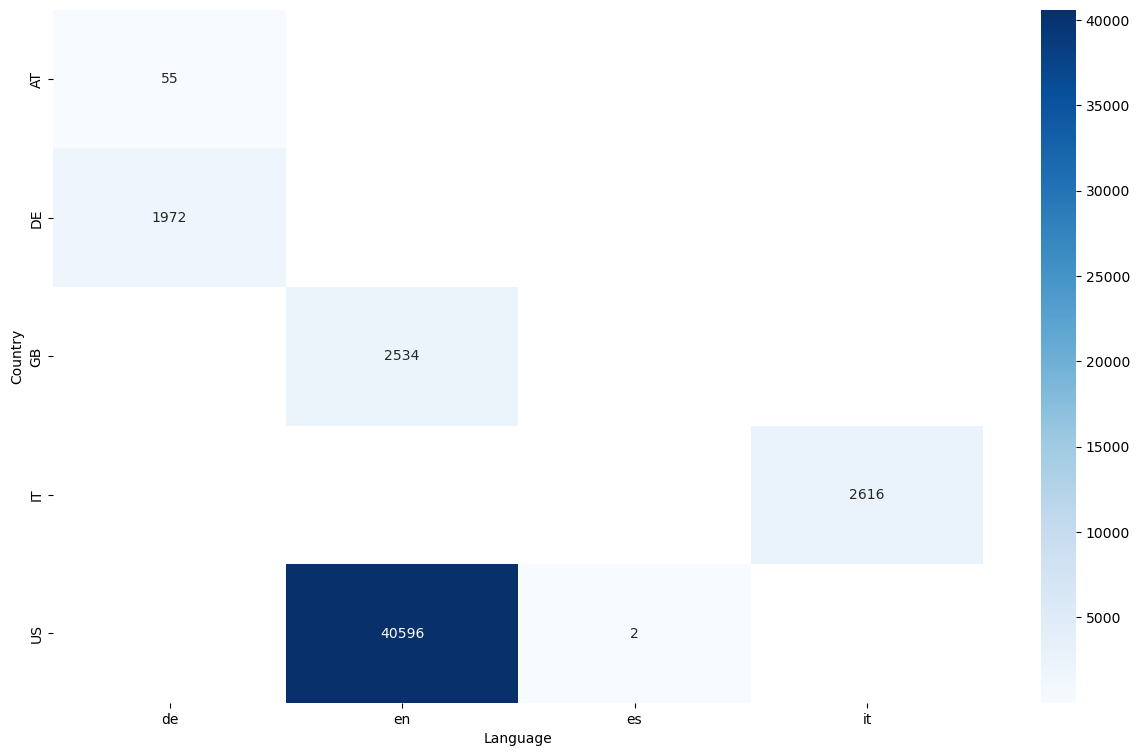

In [84]:
# heatmap with number of sources by country and language

plt.figure(figsize=(15, 9))
sns.heatmap(dataset.groupby(["Country","Language"]).size().unstack(),annot=True,fmt=".0f",cmap="Blues")
plt.show()


In [85]:
# percentage of sources with score over 60 over time rounded to 2 decimals over time
dataset.groupby(["file_date"]).Score.apply(lambda x: x.apply(lambda x: 1 if x>=60 else 0).mean()).round(3)

file_date
2019-03-01    0.714
2019-09-01    0.722
2020-03-01    0.658
2020-09-01    0.553
2021-03-01    0.576
2021-09-01    0.579
2022-03-01    0.607
2022-09-01    0.584
2023-03-01    0.577
Name: Score, dtype: float64

In [86]:

# latest ita sources
ita=dataset[dataset["Language"]=="it"]
ita=ita[ita["file_date"]==ita["file_date"].max()]

In [87]:
ita.columns

Index(['UUID', 'Domain', 'Parent Domain', 'Rating', 'Score', 'Last Updated',
       'Country', 'Language', 'Does not repeatedly publish false content',
       'Gathers and presents information responsibly',
       'Regularly corrects or clarifies errors',
       'Handles the difference between news and opinion responsibly',
       'Avoids deceptive headlines',
       'Website discloses ownership and financing',
       'Clearly labels advertising',
       'Reveals who's in charge, including any possible conflicts of interest',
       'The site provides names of content creators, along with either contact or biographical information',
       'Brand Name', 'Wikipedia', 'Type of Content', 'Medium',
       'Print Publications', 'Scope of Coverage', 'Designated Market Area',
       'Paywall', 'Opinion/Advocacy Journalism', 'Orientation', 'Owner',
       'Type of Owner', 'Facebook', 'Twitter', 'YouTube', 'Instagram',
       'Snapchat', 'LinkedIn', 'Pinterest', 'Main Point of Contact (name)',


In [88]:
# keep only Score, Orientation, Domain and criterias (the long name ones) column
ita=ita[["Score","Orientation","Domain",'Does not repeatedly publish false content',
       'Gathers and presents information responsibly',
       'Regularly corrects or clarifies errors',
       'Handles the difference between news and opinion responsibly',
       'Avoids deceptive headlines',
       'Website discloses ownership and financing',
       'Clearly labels advertising',
       "Reveals who's in charge, including any possible conflicts of interest",
       'The site provides names of content creators, along with either contact or biographical information', "Last Updated"]].sort_values(by="Score",ascending=False)


In [89]:
ita.Score.mean()

71.71670190274841

In [90]:
ita.index=ita.Domain
ita.drop(columns=["Domain"],inplace=True)

<AxesSubplot:ylabel='Frequency'>

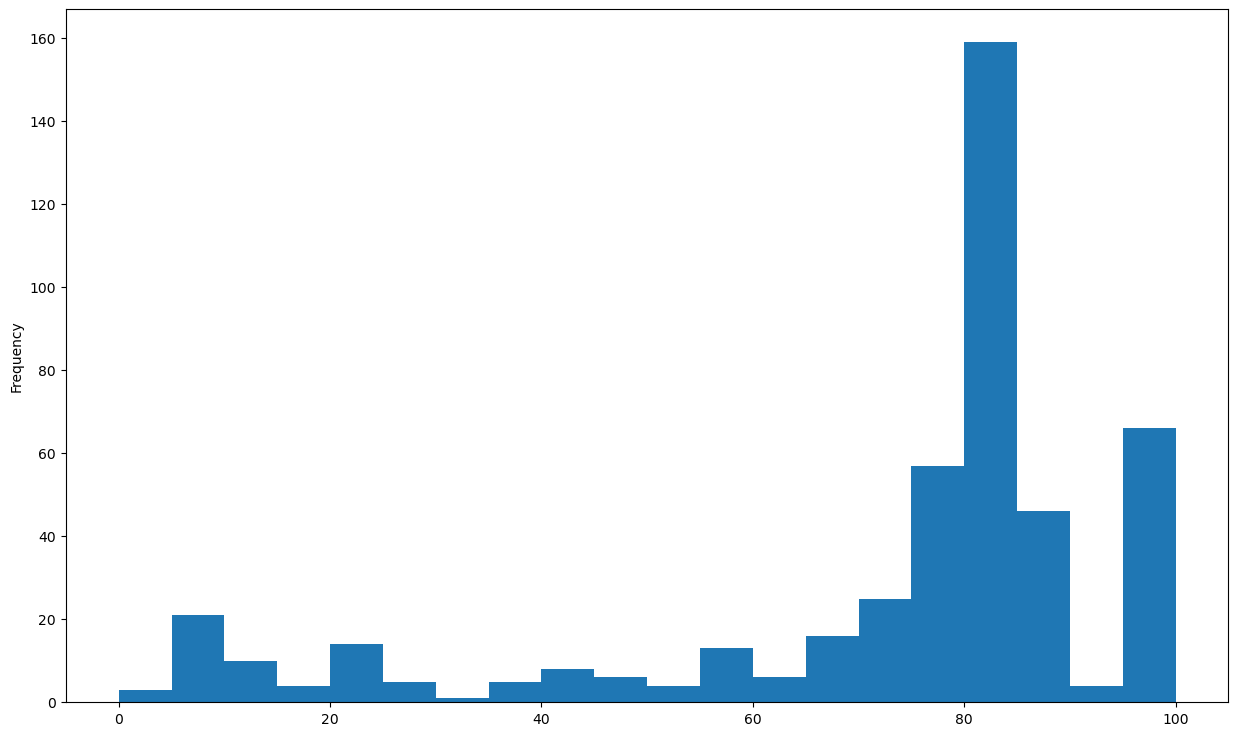

In [91]:
ita.Score.plot(kind="hist",figsize=(15, 9),bins=20)

In [92]:
ita=ita.dropna(subset=["Score"])
# last updated to datetime, unix timestamp
ita["Last Updated"]=pd.to_datetime(ita["Last Updated"],unit="ms")

In [93]:
# sort by last updated
ita=ita.sort_values(by="Last Updated",ascending=False)
ita

,Score,Orientation,Does not repeatedly publish false content,Gathers and presents information responsibly,Regularly corrects or clarifies errors,Handles the difference between news and opinion responsibly,Avoids deceptive headlines,Website discloses ownership and financing,Clearly labels advertising,"Reveals who's in charge, including any possible conflicts of interest","The site provides names of content creators, along with either contact or biographical information",Last Updated
Domain,,,,,,,,,,,,
visionetv.it,12.5,NaN,No,No,No,No,No,No,NaN,Yes,No,2023-02-28 20:07:25.778
quicosenza.it,75.0,NaN,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,2023-02-28 16:13:06.710
askanews.it,82.5,NaN,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,2023-02-28 14:41:31.125
grottaglieinrete.it,82.5,NaN,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,2023-02-28 14:18:32.022
gay.it,75.0,Left,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,2023-02-28 09:01:03.256
...,...,...,...,...,...,...,...,...,...,...,...,...
veronasera.it,82.5,NaN,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,2022-01-27 10:28:19.179
parmatoday.it,82.5,NaN,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,2022-01-27 10:23:55.647
ilpiacenza.it,82.5,NaN,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,2022-01-27 10:19:24.947


In [94]:
# find newspapers with scomodo in their domain
ita[ita.index.str.contains("leggi")]

,Score,Orientation,Does not repeatedly publish false content,Gathers and presents information responsibly,Regularly corrects or clarifies errors,Handles the difference between news and opinion responsibly,Avoids deceptive headlines,Website discloses ownership and financing,Clearly labels advertising,"Reveals who's in charge, including any possible conflicts of interest","The site provides names of content creators, along with either contact or biographical information",Last Updated
Domain,,,,,,,,,,,,
leggilo.org,70.0,Right,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,2022-07-03 14:36:31.312


## How often do German sources get updated?


In [153]:
df_total_de=df_total[df_total["Language"]=="de"]

# let's see how often german sources get updated
for time in df_total_de.file_date.unique():
    # skip first date
    if time==df_total_de.file_date.unique()[0]:
        continue
    time_index=df_total_de[df_total_de["file_date"]==time].index
    
    # dataset with current time
    current_dataset=df_total_de[df_total_de["file_date"]==time]
    # dataset with previous time using time_index-1
    prev_dataset=df_total_de[df_total_de["file_date"]==df_total_de.file_date.unique()[list(df_total_de.file_date.unique()).index(time)-1]]
    diff_dataset=pd.merge(current_dataset,prev_dataset,on="Domain",how="outer",suffixes=("_current","_previous"))
        

    

    # drop nan rows
    diff_dataset=diff_dataset.dropna(subset=["Score_current","Score_previous"])
    time=time.strftime("%Y-%m")

    # print n of changes and perc
    print(f"Date: {time}, Number of German sources: {current_dataset.shape[0]},Number of changes: {updated_sources.shape[0]}, Percentage of changes: {round(updated_sources.shape[0]/current_dataset.shape[0]*100,2)}%")
    # updated sources (sources in which the score changed)
    updated_sources=diff_dataset[diff_dataset["Score_current"]!=diff_dataset["Score_previous"]].copy()
    # calculate score diff
    updated_sources["Score_diff"]=updated_sources["Score_current"]-updated_sources["Score_previous"]
    # print the top score diff and source
    print(f"Date: {time}, Top score diff: {updated_sources['Score_diff'].max()}, Source: {updated_sources[updated_sources['Score_diff']==updated_sources['Score_diff'].max()]['Domain'].values[0]}, previous score: {updated_sources[updated_sources['Score_diff']==updated_sources['Score_diff'].max()]['Score_previous'].values[0]}, current score: {updated_sources[updated_sources['Score_diff']==updated_sources['Score_diff'].max()]['Score_current'].values[0]}")

Date: 2020-03, Number of German sources: 213,Number of changes: 42, Percentage of changes: 19.72%
Date: 2020-03, Top score diff: 12.5, Source: bz-berlin.de, previous score: 82.5, current score: 95.0
Date: 2020-09, Number of German sources: 248,Number of changes: 10, Percentage of changes: 4.03%
Date: 2020-09, Top score diff: 12.5, Source: ruhrnachrichten.de, previous score: 87.5, current score: 100.0
Date: 2021-03, Number of German sources: 270,Number of changes: 3, Percentage of changes: 1.11%
Date: 2021-03, Top score diff: 25.0, Source: rollingstone.de, previous score: 70.0, current score: 95.0
Date: 2021-09, Number of German sources: 273,Number of changes: 54, Percentage of changes: 19.78%
Date: 2021-09, Top score diff: 39.5, Source: medizin-heute.net, previous score: 12.5, current score: 52.0
Date: 2022-03, Number of German sources: 279,Number of changes: 27, Percentage of changes: 9.68%
Date: 2022-03, Top score diff: 12.5, Source: derwesten.de, previous score: 72.5, current score:

C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\1925032018.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total_de["file_date"]=pd.to_datetime(df_total_de["file_date"])
C:\Users\rmlaz\AppData\Local\Temp\ipykernel_17472\1925032018.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total_de["file_date"] = pd.to_datetime(df_total_de["file_date"])


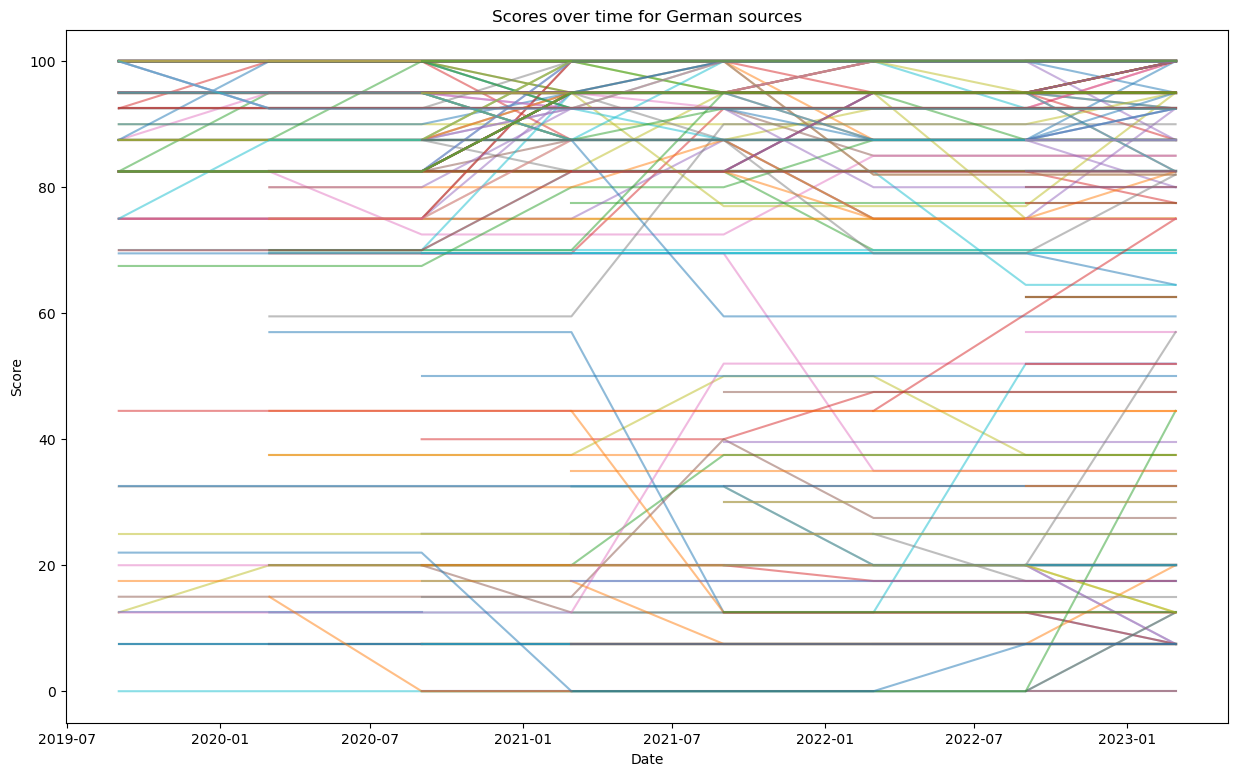

In [159]:
# get all scores over the years for every german source
# x axis is time, y axis is score
# make a line plot with all the scores over time for every german source

df_total_de["file_date"]=pd.to_datetime(df_total_de["file_date"])

import matplotlib.pyplot as plt

# convert file_date to datetime
df_total_de["file_date"] = pd.to_datetime(df_total_de["file_date"])

# create a line plot for each domain
fig, ax = plt.subplots(figsize=(15, 9))
for domain, data in df_total_de.groupby("Domain"):
    ax.plot(data["file_date"], data["Score"], label=domain, alpha=0.5)

# set plot title and axis labels
ax.set_title("Scores over time for German sources")
ax.set_xlabel("Date")
ax.set_ylabel("Score")



plt.show()


,UUID_x,Domain,Parent Domain_x,Rating_x,Score_x,Last Updated_x,Country,Language_x,Does not repeatedly publish false content_x,Gathers and presents information responsibly_x,...,iOS App_y,Android App_y,Original Reporting_y,Targeted Audience_y,Contact Mail Form URL.1_y,Other_y,False Narratives_y,Communities Served_y,BrandGuard Segments_y,_merge
0,986c8632-636e-4dbf-9e5d-13ff7060dfeb,zackzack.at,NaN,T,87.5,1.661406e+12,AT,de,Yes,Yes,...,https://apps.apple.com/de/app/zackzack-das-onl...,https://play.google.com/store/apps/details?id=...,Yes,National,NaN,NaN,NaN,NaN,"Inclusion - Maximum Safety,Inclusion - High Sa...",both
1,3c93a771-dbb9-4552-9f46-f74c7e7caa06,vienna.at,NaN,T,82.5,1.661406e+12,AT,de,Yes,Yes,...,https://apps.apple.com/us/app/vienna-at-vienna...,https://play.google.com/store/apps/details?id=...,Yes,"Local,Regional,National",NaN,NaN,NaN,NaN,"Inclusion - Maximum Safety,Inclusion - High Sa...",both
2,7de5bcf9-d524-4ad3-a2d2-f8218cd001b4,servustv.com,NaN,N,52.0,1.661406e+12,AT,de,Yes,No,...,NaN,NaN,Yes,National,https://www.servustv.com/allgemein/p/servuskon...,NaN,"cee6c559-7d71-40ec-a04f-3acf91c17878,44c7feea-...",NaN,"Exclusion - Maximum Safety,Exclusion - High Sa...",both
3,143d9a02-fe66-4d04-878b-1a68127fc798,puls24.at,NaN,T,95.0,1.661406e+12,AT,de,Yes,Yes,...,https://apps.apple.com/at/app/id385942785,https://play.google.com/store/apps/details?id=...,Yes,National,https://www.puls24.at/kontakt,NaN,NaN,NaN,"Inclusion - Maximum Safety,Inclusion - High Sa...",both
4,9a05ddc4-0860-4a34-aa14-da2c35e871f3,dietagespresse.com,NaN,S,NaN,1.661406e+12,AT,de,NaN,NaN,...,https://apps.apple.com/de/app/tagespresse/id10...,https://play.google.com/store/apps/details?id=...,Yes,"National,International",NaN,NaN,NaN,NaN,NaN,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,NaN,tip-berlin.de,NaN,NaN,NaN,NaN,DE,NaN,NaN,NaN,...,NaN,NaN,Yes,Local,NaN,NaN,NaN,NaN,"Inclusion - Basic Safety,Exclusion - Maximum S...",right_only
343,NaN,sn.at,NaN,NaN,NaN,NaN,AT,NaN,NaN,NaN,...,https://apps.apple.com/at/app/salzburger-nachr...,https://play.google.com/store/apps/details?id=...,Yes,"Regional,National",NaN,NaN,NaN,NaN,"Inclusion - Maximum Safety,Inclusion - High Sa...",right_only
344,NaN,gentside.de,NaN,NaN,NaN,NaN,DE,NaN,NaN,NaN,...,NaN,NaN,No,National,NaN,https://www.pinterest.com/gentside_de/,NaN,NaN,"Inclusion - Maximum Safety,Inclusion - High Sa...",right_only
345,NaN,radiobrocken.de,NaN,NaN,NaN,NaN,DE,NaN,NaN,NaN,...,https://apps.apple.com/de/app/radio-brocken/id...,https://play.google.com/store/apps/details?id=...,Yes,Regional,redaktion@funkhaus-halle.de,https://www.pinterest.com/radiobrocken/,NaN,NaN,"Inclusion - Maximum Safety,Inclusion - High Sa...",right_only
